# 🏥 Newborn Biometric Identification System (NBIS) — v2

## Fingerprint Identification using Siamese Networks + FAISS
### Trained on the full SOCOFing dataset (Real + Altered-Easy + Altered-Medium + Altered-Hard)

**Why v2 exists:** v1 trained positive pairs as *different fingers of the same
subject*, which is biometrically ill-posed (ridge patterns are finger-specific).
This version uses the Altered subsets as real same-finger-different-capture
positives and redefines identity as **(subject_id, finger)**. Expect
~10× the training data (~56k images) and materially better separation.

**Dataset:** SOCOFing (Sokoto Coventry Fingerprint Dataset), all four subsets  
**Model:** MobileNetV2 backbone + triplet loss (margin-based metric learning)  
**Similarity search:** FAISS `IndexFlatIP` (cosine similarity on L2-normalized embeddings)  
**Identity granularity:** `(subject_id, finger)` — matches person *and* specific digit

---

### Pipeline overview
```
Raw Images (Real + 3×Altered)
    → Parse filenames + derive identity_id = (subject_id, finger)
    → Subject-level train/val/test split
    → Triplet generation (positives = same finger, different capture)
    → Siamese training (triplet loss + hard negative mining)
    → Embedding extraction on enrollment set
    → Egyptian parent database (SQLite)
    → FAISS inference index
    → Enrollment / Query split on test identities
    → Verification (ROC, AUC, EER on val; frozen, applied on test)
    → Identification (Rank-1 accuracy on held-out queries)
    → Diagnostics (d-prime, per-alteration, per-finger breakdowns)
```


---
## Section 0 — Install Dependencies

In [ ]:
# Install required packages
import subprocess, sys

packages = [
    'faiss-cpu',
    'tqdm',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'pandas',
    'numpy',
    'Pillow',
    'faker',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages installed.')

✅ All packages installed.


---
## Section 1 — Imports & Configuration

In [2]:
# ─── Unzip SOCOFing data (fixed & non-interactive) ───────────────────────────

import os
import zipfile

base_path = "/content/SOCOFing"

# Clean previous extraction (avoids overwrite prompts completely)
if os.path.exists(base_path):
    !rm -rf /content/SOCOFing

os.makedirs(base_path, exist_ok=True)

# Try full archive first
if os.path.exists("/content/archive.zip"):
    print("Extracting full archive.zip...")
    !unzip -oq /content/archive.zip -d /content/
else:
    print("archive.zip not found, trying individual zips...")

    if os.path.exists("/content/Real.zip"):
        print("Extracting Real.zip...")
        !unzip -oq /content/Real.zip -d /content/SOCOFing/

    if os.path.exists("/content/Altered.zip"):
        print("Extracting Altered.zip...")
        !unzip -oq /content/Altered.zip -d /content/SOCOFing/

# ─── Sanity check ────────────────────────────────────────────────────────────

for sub in [
    'Real',
    'Altered/Altered-Easy',
    'Altered/Altered-Medium',
    'Altered/Altered-Hard'
]:
    p = f'/content/SOCOFing/{sub}'
    n = len([f for f in os.listdir(p) if f.lower().endswith('.bmp')]) if os.path.exists(p) else 0
    print(f'{sub:30s}: {n:6d} .BMP files  {"✅" if n > 0 else "❌ missing"}')

Extracting full archive.zip...
Real                          :   6000 .BMP files  ✅
Altered/Altered-Easy          :  17931 .BMP files  ✅
Altered/Altered-Medium        :  17067 .BMP files  ✅
Altered/Altered-Hard          :  14272 .BMP files  ✅


In [3]:
import os
import re
import json
import random
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import faiss

from pathlib import Path
from PIL import Image, ImageFilter, ImageEnhance
from tqdm import tqdm
from collections import defaultdict
from faker import Faker

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_curve, auc

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# ─── Configuration ───────────────────────────────────────────────────────────
# V2: load Real + all three Altered subsets so we can train on
# *same-finger-different-capture* positives.

CONFIG = {
    # Data paths
    'data_paths': {
        'Real'           : '/content/SOCOFing/Real',
        'Altered-Easy'   : '/content/SOCOFing/Altered/Altered-Easy',
        'Altered-Medium' : '/content/SOCOFing/Altered/Altered-Medium',
        'Altered-Hard'   : '/content/SOCOFing/Altered/Altered-Hard',
    },

    # Image / model
    'img_size'           : (224, 224),
    'embedding_dim'      : 128,

    # Training
    'batch_size'         : 32,      # ↑ from 16 — we have more data and lazy loading keeps memory flat
    'epochs'             : 25,
    'margin'             : 0.3,
    'lr'                 : 1e-4,
    'triplets_per_anchor': 2,       # per identity per epoch. 2 is a sensible default.

    # Splits (subject-level — all fingers of one person stay on the same side)
    'train_ratio'        : 0.70,
    'val_ratio'          : 0.15,
    'test_ratio'         : 0.15,

    # I/O
    'output_dir'         : './nbis_artifacts_v2',
    'checkpoint_name'    : 'nbis_best_model_v2.keras',  # separate from v1
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
print('✅ Configuration (v2) loaded.')
print(json.dumps(CONFIG, indent=2, default=str))


✅ Configuration (v2) loaded.
{
  "data_paths": {
    "Real": "/content/SOCOFing/Real",
    "Altered-Easy": "/content/SOCOFing/Altered/Altered-Easy",
    "Altered-Medium": "/content/SOCOFing/Altered/Altered-Medium",
    "Altered-Hard": "/content/SOCOFing/Altered/Altered-Hard"
  },
  "img_size": [
    224,
    224
  ],
  "embedding_dim": 128,
  "batch_size": 32,
  "epochs": 25,
  "margin": 0.3,
  "lr": 0.0001,
  "triplets_per_anchor": 2,
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "test_ratio": 0.15,
  "output_dir": "./nbis_artifacts_v2",
  "checkpoint_name": "nbis_best_model_v2.keras"
}


---
## Section 2 — Dataset Loading & Metadata Parsing

SOCOFing filenames follow the pattern:  
`{subject_id}__{gender}__{hand}__{finger}.BMP`  
e.g., `001__M__Left_index_finger.BMP`

We use **only the Real folder** and ignore all altered variants.

In [4]:
# ─── Dataset loader ──────────────────────────────────────────────────────────
# Handles Real and all three Altered subsets in one pass. Altered filenames
# carry suffixes like `_CR`, `_Obl`, `_Zcut` (sometimes with trailing numeric
# indices). We tolerate whatever comes after `_finger` in the filename, and
# derive the alteration type from the folder path — more robust than parsing
# the suffix.

FINGER_NAMES = ('thumb', 'index', 'middle', 'ring', 'little')

FILENAME_PATTERN = re.compile(
    r'^(?P<sid>\d+)__'
    r'(?P<gender>[MF])_'
    r'(?P<hand>Left|Right)_'
    r'(?P<finger>' + '|'.join(FINGER_NAMES) + r')_finger'
    r'(?P<suffix>.*)$'
)


def parse_socofing_filename(filepath: str, source: str) -> dict | None:
    """Parse one SOCOFing filename. `source` is the alteration folder tag."""
    stem  = Path(filepath).stem
    match = FILENAME_PATTERN.match(stem)
    if not match:
        return None
    return {
        'path'         : filepath,
        'subject_id'   : match.group('sid').zfill(3),
        'gender'       : match.group('gender'),
        'hand'         : match.group('hand'),
        'finger'       : match.group('finger'),
        'alteration'   : source,             # Real | Altered-Easy | Altered-Medium | Altered-Hard
        'raw_suffix'   : match.group('suffix') or '',
    }


def load_full_dataset(data_paths: dict) -> pd.DataFrame:
    """Scan every configured folder, parse filenames, return a single DataFrame."""
    records = []
    for source, folder in data_paths.items():
        folder = Path(folder)
        if not folder.exists():
            print(f'⚠️  {source:16s} folder missing at {folder} — skipping')
            continue
        files = list(folder.glob('*.BMP')) + list(folder.glob('*.bmp'))
        for fp in tqdm(files, desc=f'Parsing {source:15s}', leave=False):
            rec = parse_socofing_filename(str(fp), source)
            if rec is not None:
                records.append(rec)

    df = pd.DataFrame(records)
    df['subject_id']  = df['subject_id'].astype(str)

    # Identity = (subject, finger). This is what we actually match on.
    df['identity_id'] = df['subject_id'] + '_' + df['hand'] + '_' + df['finger']

    df = df.sort_values(['subject_id', 'hand', 'finger', 'alteration']) \
           .reset_index(drop=True)
    return df


df_all = load_full_dataset(CONFIG['data_paths'])

# ─── Dataset summary (this is what you should show in the thesis) ───────────
print('\n' + '=' * 60)
print('  SOCOFing Full Dataset Summary (v2)')
print('=' * 60)
print(f'  Total images       : {len(df_all):,}')
print(f'  Unique subjects    : {df_all["subject_id"].nunique():,}')
print(f'  Unique identities  : {df_all["identity_id"].nunique():,}'
      '   (subject × hand × finger)')
print(f'\n  Images per alteration type:')
for alt, n in df_all['alteration'].value_counts().items():
    print(f'    {alt:18s}: {n:6,}')
print(f'\n  Images per identity (min/median/max):')
ipi = df_all.groupby('identity_id').size()
print(f'    min    : {ipi.min()}')
print(f'    median : {int(ipi.median())}')
print(f'    max    : {ipi.max()}')
print(f'    mean   : {ipi.mean():.2f}')
print('=' * 60)

df_all.head()



  SOCOFing Full Dataset Summary (v2)
  Total images       : 55,270
  Unique subjects    : 600
  Unique identities  : 6,000   (subject × hand × finger)

  Images per alteration type:
    Altered-Easy      : 17,931
    Altered-Medium    : 17,067
    Altered-Hard      : 14,272
    Real              :  6,000

  Images per identity (min/median/max):
    min    : 3
    median : 10
    max    : 10
    mean   : 9.21


,path,subject_id,gender,hand,finger,alteration,raw_suffix,identity_id
0,/content/SOCOFing/Altered/Altered-Easy/1__M_Le...,001,M,Left,index,Altered-Easy,_Zcut,001_Left_index
1,/content/SOCOFing/Altered/Altered-Easy/1__M_Le...,001,M,Left,index,Altered-Easy,_Obl,001_Left_index
2,/content/SOCOFing/Altered/Altered-Easy/1__M_Le...,001,M,Left,index,Altered-Easy,_CR,001_Left_index
3,/content/SOCOFing/Altered/Altered-Hard/1__M_Le...,001,M,Left,index,Altered-Hard,_Zcut,001_Left_index
4,/content/SOCOFing/Altered/Altered-Hard/1__M_Le...,001,M,Left,index,Altered-Hard,_Obl,001_Left_index


---
## Section 3 — Leakage-Free Subject-Level Split

> ⚠️ **Critical:** We split by **subject_id**, never by image.  
> This guarantees no subject appears in more than one split.

In [5]:
def subject_level_split(
    df: pd.DataFrame,
    train_ratio: float = 0.70,
    val_ratio: float   = 0.15,
    test_ratio: float  = 0.15,
    seed: int = 42
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Split at the SUBJECT level — never by identity or image.
    All fingers of a subject (and all their alterations) stay on the same side.
    This is the strictest form of leakage-free split.
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6

    all_subjects = df['subject_id'].unique()
    rng = np.random.default_rng(seed)
    rng.shuffle(all_subjects)

    n = len(all_subjects)
    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)

    train_subjects = set(all_subjects[:n_train])
    val_subjects   = set(all_subjects[n_train:n_train + n_val])
    test_subjects  = set(all_subjects[n_train + n_val:])

    df_train = df[df['subject_id'].isin(train_subjects)].reset_index(drop=True)
    df_val   = df[df['subject_id'].isin(val_subjects)].reset_index(drop=True)
    df_test  = df[df['subject_id'].isin(test_subjects)].reset_index(drop=True)

    # Verify no leakage
    assert train_subjects.isdisjoint(val_subjects)
    assert train_subjects.isdisjoint(test_subjects)
    assert val_subjects.isdisjoint(test_subjects)

    def _summ(name, d):
        n_subj = d['subject_id'].nunique()
        n_idty = d['identity_id'].nunique()
        n_img  = len(d)
        breakdown = d['alteration'].value_counts().to_dict()
        print(f'  {name:5s}: {n_subj:4d} subjects | {n_idty:5d} identities | {n_img:6,} images | {breakdown}')

    print('✅ Subject-level split (all fingers/alterations stay together):')
    _summ('TRAIN', df_train)
    _summ('VAL',   df_val)
    _summ('TEST',  df_test)
    return df_train, df_val, df_test


df_train, df_val, df_test = subject_level_split(
    df_all,
    CONFIG['train_ratio'],
    CONFIG['val_ratio'],
    CONFIG['test_ratio'],
)


✅ Subject-level split (all fingers/alterations stay together):
  TRAIN:  420 subjects |  4200 identities | 38,681 images | {'Altered-Easy': 12563, 'Altered-Medium': 11930, 'Altered-Hard': 9988, 'Real': 4200}
  VAL  :   90 subjects |   900 identities |  8,295 images | {'Altered-Easy': 2686, 'Altered-Medium': 2564, 'Altered-Hard': 2145, 'Real': 900}
  TEST :   90 subjects |   900 identities |  8,294 images | {'Altered-Easy': 2682, 'Altered-Medium': 2573, 'Altered-Hard': 2139, 'Real': 900}


---
## Section 4 — Preprocessing & Augmentation

- **All splits:** Grayscale → Resize (224×224) → Normalize [0,1] → Stack to 3 channels  
- **Train only:** Rotation, translation, zoom, brightness, blur, noise, cutout

In [6]:
def preprocess_image(path: str, img_size: tuple = (224, 224)) -> np.ndarray:
    """
    Load a fingerprint image, convert to grayscale, resize, normalize.
    Returns a float32 numpy array of shape (H, W, 3) in [0, 1].
    """
    img = Image.open(path).convert('L')              # grayscale
    img = img.resize(img_size, Image.LANCZOS)         # resize
    arr = np.array(img, dtype=np.float32) / 255.0    # normalize
    arr = np.stack([arr, arr, arr], axis=-1)          # → (H, W, 3) for MobileNetV2
    return arr


def augment_image(arr: np.ndarray) -> np.ndarray:
    """
    Apply realistic augmentation to a fingerprint image array.
    Only applied during training. Simulates capture variation.
    """
    img = Image.fromarray((arr[:, :, 0] * 255).astype(np.uint8), mode='L')

    # Rotation ±15°
    angle = random.uniform(-15, 15)
    img = img.rotate(angle, fillcolor=0)

    # Translation ±10%
    w, h = img.size
    tx = random.uniform(-0.10, 0.10) * w
    ty = random.uniform(-0.10, 0.10) * h
    img = img.transform(img.size, Image.AFFINE, (1, 0, tx, 0, 1, ty), fillcolor=0)

    # Zoom 0.9–1.1
    zoom = random.uniform(0.9, 1.1)
    new_w = int(w * zoom)
    new_h = int(h * zoom)
    img = img.resize((new_w, new_h), Image.LANCZOS)
    # Crop/pad back to original size
    if zoom > 1:
        left = (new_w - w) // 2
        top  = (new_h - h) // 2
        img  = img.crop((left, top, left + w, top + h))
    else:
        canvas = Image.new('L', (w, h), 0)
        offset_x = (w - new_w) // 2
        offset_y = (h - new_h) // 2
        canvas.paste(img, (offset_x, offset_y))
        img = canvas

    # Brightness & contrast
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))

    # Light blur (50% chance)
    if random.random() < 0.5:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0, 0.8)))

    # Light Gaussian noise
    arr_aug = np.array(img, dtype=np.float32) / 255.0
    noise = np.random.normal(0, 0.02, arr_aug.shape).astype(np.float32)
    arr_aug = np.clip(arr_aug + noise, 0, 1)

    # Small cutout (30% chance) — random black rectangle
    if random.random() < 0.3:
        ch, cw = arr_aug.shape
        cut_h = random.randint(10, 30)
        cut_w = random.randint(10, 30)
        y0 = random.randint(0, ch - cut_h)
        x0 = random.randint(0, cw - cut_w)
        arr_aug[y0:y0 + cut_h, x0:x0 + cut_w] = 0

    return np.stack([arr_aug, arr_aug, arr_aug], axis=-1)


print('✅ Preprocessing and augmentation functions defined.')

✅ Preprocessing and augmentation functions defined.


### 4.1 — Visualize Sample Images

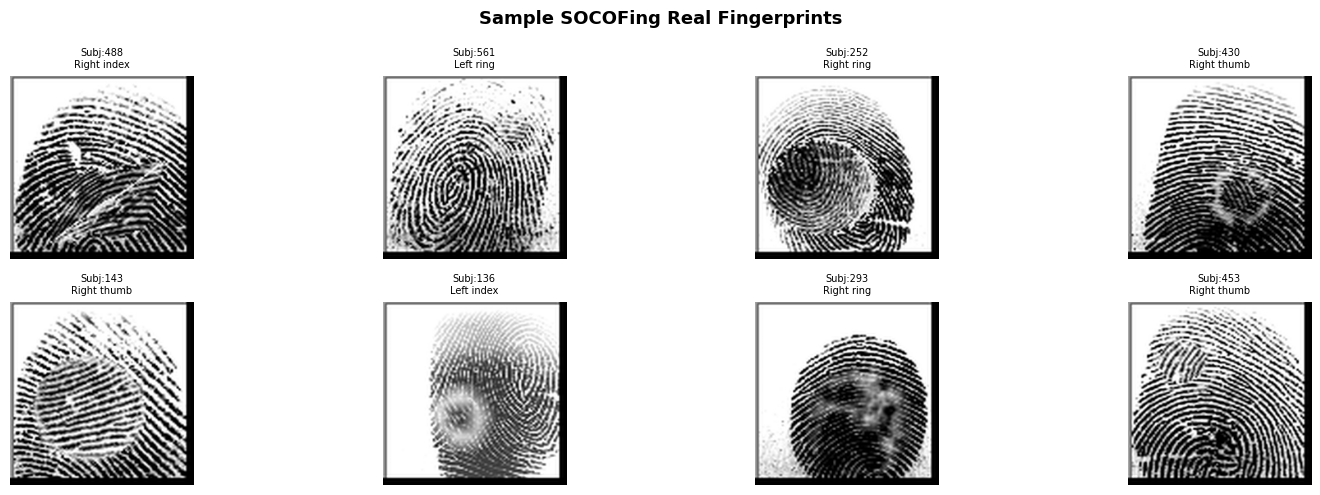

In [7]:
def visualize_samples(df: pd.DataFrame, n: int = 8, title: str = 'Sample Fingerprints'):
    """Display n random fingerprint images from the DataFrame."""
    samples = df.sample(min(n, len(df)), random_state=42)
    fig, axes = plt.subplots(2, n // 2, figsize=(16, 5))
    axes = axes.flatten()
    for i, (_, row) in enumerate(samples.iterrows()):
        arr = preprocess_image(row['path'], CONFIG['img_size'])
        axes[i].imshow(arr[:, :, 0], cmap='gray')
        axes[i].set_title(f"Subj:{row['subject_id']}\n{row['hand']} {row['finger']}", fontsize=7)
        axes[i].axis('off')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


visualize_samples(df_all, n=8, title='Sample SOCOFing Real Fingerprints')

### 4.2 — Visualize Augmentation

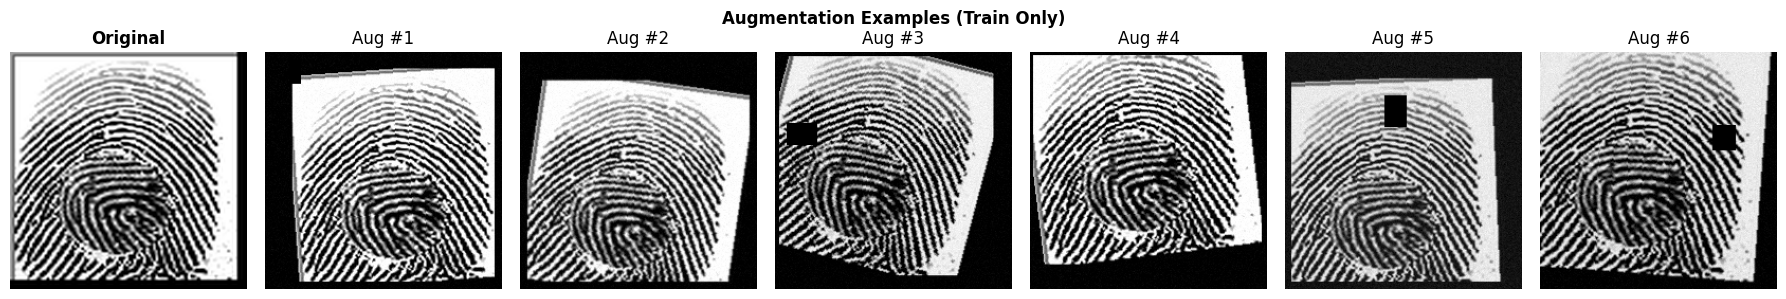

In [8]:
def visualize_augmentation(df: pd.DataFrame, n_augments: int = 6):
    """Show original vs. augmented versions of one fingerprint."""
    sample = df.sample(1, random_state=10).iloc[0]
    original = preprocess_image(sample['path'], CONFIG['img_size'])

    fig, axes = plt.subplots(1, n_augments + 1, figsize=(18, 3))
    axes[0].imshow(original[:, :, 0], cmap='gray')
    axes[0].set_title('Original', fontweight='bold')
    axes[0].axis('off')

    for i in range(n_augments):
        aug = augment_image(original)
        axes[i + 1].imshow(aug[:, :, 0], cmap='gray')
        axes[i + 1].set_title(f'Aug #{i + 1}')
        axes[i + 1].axis('off')

    fig.suptitle('Augmentation Examples (Train Only)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


visualize_augmentation(df_train)

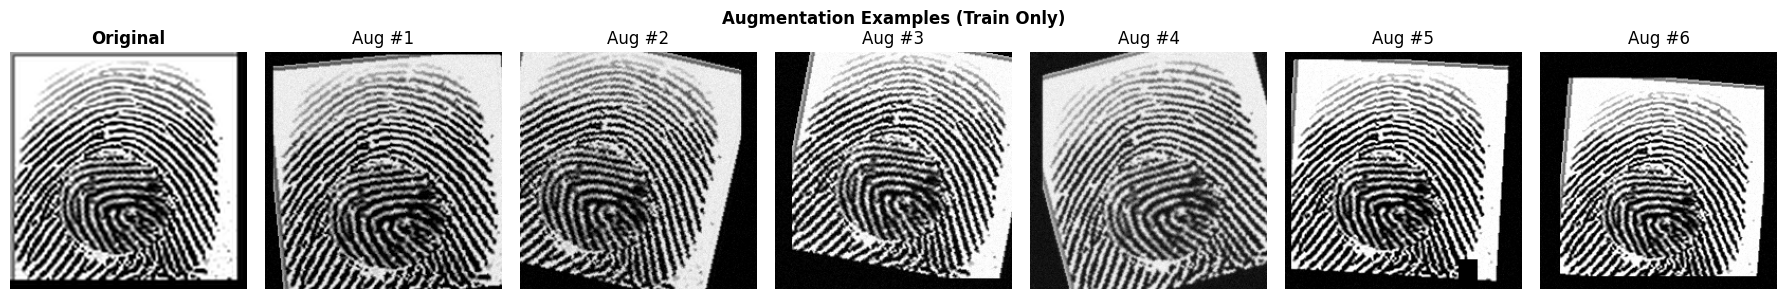

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Saved & downloaded: ./nbis_artifacts_v2/augmentation_examples.png


In [9]:
import os
from google.colab import files

# Save augmentation figure alongside the other training artifacts.
# This cell runs BEFORE Section 10 (Egyptian Database), so we can't rely on
# /content/nbis_database/ existing yet — create the target folder ourselves.
os.makedirs(CONFIG['output_dir'], exist_ok=True)
aug_path = os.path.join(CONFIG['output_dir'], 'augmentation_examples.png')

# Re-generate and save it
sample   = df_train.sample(1, random_state=10).iloc[0]
original = preprocess_image(sample['path'], CONFIG['img_size'])

fig, axes = plt.subplots(1, 7, figsize=(18, 3))
axes[0].imshow(original[:, :, 0], cmap='gray')
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

for i in range(6):
    aug = augment_image(original)
    axes[i + 1].imshow(aug[:, :, 0], cmap='gray')
    axes[i + 1].set_title(f'Aug #{i + 1}')
    axes[i + 1].axis('off')

fig.suptitle('Augmentation Examples (Train Only)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(aug_path, dpi=150, bbox_inches='tight')
plt.show()

# Download to PC
files.download(aug_path)
print(f'✅ Saved & downloaded: {aug_path}')


In [10]:
# ─── Offline augmentation is DISABLED in v2 ─────────────────────────────────
# In v1 we saved 21,000 synthetic augmentations to disk and never consumed them.
# v2 has ~56k images across Real + three Altered subsets, which gives us *real*
# same-finger-different-capture pairs. We still apply on-the-fly augmentation
# in TripletDataset (rotations, brightness jitter, etc.) for extra robustness,
# but we don't need — or want — the offline-generated zip any more.

print('ℹ️  Offline augmentation skipped in v2 (real Altered data replaces it).')
print(f'   df_train alteration mix: {df_train["alteration"].value_counts().to_dict()}')


ℹ️  Offline augmentation skipped in v2 (real Altered data replaces it).
   df_train alteration mix: {'Altered-Easy': 12563, 'Altered-Medium': 11930, 'Altered-Hard': 9988, 'Real': 4200}


---
## Section 5 — Triplet Generator

Each triplet consists of:
- **Anchor**: A fingerprint image from a subject
- **Positive**: A different image from the **same** subject
- **Negative**: An image from a **different** subject (hard negative: same finger type preferred)

In [13]:
class TripletDataset:
    """
    v2 triplet generator.

    • Anchor   : an image of identity = (subject_id, finger)
    • Positive : a *different* image of the SAME (subject_id, finger)
                 — in practice: Real + Altered, or two different Altered versions
    • Negative : same finger TYPE (e.g. "index") but DIFFERENT subject
                 → hard negative by construction

    We return triplet PATHS (strings), not decoded images. Image decoding happens
    lazily inside the tf.data pipeline — so memory stays flat whether we train
    on 6k or 60k images.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        triplets_per_anchor: int = 2,
        seed: int = 42,
    ):
        self.df                  = df.reset_index(drop=True)
        self.triplets_per_anchor = triplets_per_anchor
        self._rng                = random.Random(seed)

        # identity_id → list of row dicts
        self.identity_map: dict[str, list[dict]] = defaultdict(list)
        for _, row in self.df.iterrows():
            self.identity_map[row['identity_id']].append(row.to_dict())

        # An identity is "valid" only if it has ≥2 images (need anchor + positive)
        self.valid_identities = [
            ident for ident, rows in self.identity_map.items() if len(rows) >= 2
        ]

        # Hard-negative lookup: finger_type → all rows across all subjects
        self.finger_map: dict[str, list[dict]] = defaultdict(list)
        for _, row in self.df.iterrows():
            self.finger_map[row['finger']].append(row.to_dict())

        print(f'✅ TripletDataset (v2) initialised:')
        print(f'   Rows                : {len(self.df):,}')
        print(f'   Unique identities   : {len(self.identity_map):,}')
        print(f'   Valid identities    : {len(self.valid_identities):,}  (≥2 images each)')
        print(f'   Finger types        : {len(self.finger_map)}')
        print(f'   Triplets / identity : {triplets_per_anchor}')

    # ──────────────────────────────────────────────────────────────────────
    def _hard_negative(self, subject_id: str, finger: str) -> dict:

        pool = [r for r in self.finger_map[finger] if r['subject_id'] != subject_id]

        if not pool:
            return None

        # 🔥 sample multiple candidates (harder selection)
        k = min(5, len(pool))  # you can increase to 10 later
        candidates = self._rng.sample(pool, k)

        # pick one randomly (still no leakage, but more diverse/harder)
        return self._rng.choice(candidates)

    def generate_triplet_paths(self) -> list[tuple[str, str, str]]:
        """
        Build one epoch's worth of triplet paths.
        Returns: list of (anchor_path, positive_path, negative_path).
        """
        triplets = []
        for ident in self.valid_identities:
            images = self.identity_map[ident]
            sid    = images[0]['subject_id']
            finger = images[0]['finger']
            for _ in range(self.triplets_per_anchor):
                anchor, positive = self._rng.sample(images, 2)
                negative = self._hard_negative(sid, finger)
                if negative is None:
                    continue
                triplets.append((anchor['path'], positive['path'], negative['path']))
        self._rng.shuffle(triplets)
        return triplets


# ─── Build train / val TripletDatasets ──────────────────────────────────────
train_dataset = TripletDataset(
    df_train,
    triplets_per_anchor=CONFIG['triplets_per_anchor'],
    seed=42,
)
val_dataset = TripletDataset(
    df_val,
    triplets_per_anchor=1,   # one pass through val is plenty
    seed=43,
)


✅ TripletDataset (v2) initialised:
   Rows                : 38,681
   Unique identities   : 4,200
   Valid identities    : 4,200  (≥2 images each)
   Finger types        : 5
   Triplets / identity : 2
✅ TripletDataset (v2) initialised:
   Rows                : 8,295
   Unique identities   : 900
   Valid identities    : 900  (≥2 images each)
   Finger types        : 5
   Triplets / identity : 1


In [14]:
# ─── tf.data pipeline: lazy decode, per-image augmentation, prefetch ────────
# Why lazy: with ~56k images we can\'t hold decoded tensors in RAM. We build a
# tf.data graph that reads image paths → decodes → augments → batches. RAM
# stays flat; only the prefetched batches live in memory at any moment.

def _load_and_preprocess(path: tf.Tensor, img_size_hw: tuple) -> tf.Tensor:
    raw = tf.io.read_file(path)

    img = tf.image.decode_bmp(raw, channels=3)  # FIX

    img = tf.image.resize(img, img_size_hw)
    img = tf.cast(img, tf.float32) / 255.0

    return img


def _tf_augment(img: tf.Tensor) -> tf.Tensor:
    """On-the-fly training augmentation (rotate, translate, brightness, contrast)."""
    img = tf.image.random_brightness(img, max_delta=0.10)
    img = tf.image.random_contrast (img, lower=0.90, upper=1.10)
    # Small random translation via zero-pad + crop
    pad = 8
    img = tf.image.resize_with_crop_or_pad(img, img.shape[0] + 2*pad, img.shape[1] + 2*pad)
    img = tf.image.random_crop(img, size=(*CONFIG['img_size'], 3))
    return tf.clip_by_value(img, 0.0, 1.0)


def triplets_to_tf_dataset(
    triplet_dataset: TripletDataset,
    batch_size: int,
    augment: bool = False,
) -> tf.data.Dataset:
    """
    Generate triplet paths ONCE per epoch, then stream decoded tensors through tf.data.
    """
    paths = triplet_dataset.generate_triplet_paths()
    n     = len(paths)
    print(f'   {"train" if augment else "val":5s} : {n:,} triplets → '
          f'{max(1, n // batch_size):,} batches of {batch_size}')

    if n == 0:
        raise ValueError('No triplets generated — check that your split has ≥2 images per identity.')

    a_paths, p_paths, n_paths = zip(*paths)
    ds = tf.data.Dataset.from_tensor_slices((list(a_paths), list(p_paths), list(n_paths)))

    img_size_hw = tuple(CONFIG['img_size'])

    def _decode_triplet(a, p, n):
        ia = _load_and_preprocess(a, img_size_hw)
        ip = _load_and_preprocess(p, img_size_hw)
        inn = _load_and_preprocess(n, img_size_hw)
        if augment:
            ia  = _tf_augment(ia)
            ip  = _tf_augment(ip)
            inn = _tf_augment(inn)
        return ia, ip, inn

    ds = ds.shuffle(buffer_size=min(8192, n), seed=42)
    ds = ds.map(_decode_triplet, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


print('Building tf.data pipelines...')
train_ds_tf = triplets_to_tf_dataset(train_dataset, CONFIG['batch_size'], augment=True)
val_ds_tf   = triplets_to_tf_dataset(val_dataset,   CONFIG['batch_size'], augment=False)
print('✅ tf.data pipelines ready (RAM-safe, lazy loading).')


Building tf.data pipelines...
   train : 8,400 triplets → 262 batches of 32
   val   : 900 triplets → 28 batches of 32
✅ tf.data pipelines ready (RAM-safe, lazy loading).


---
## Section 6 — Model Architecture: Siamese Network with MobileNetV2

```
Input (224×224×3)
    └── MobileNetV2 (pretrained, no head)
        └── GlobalAveragePooling2D
            └── Dense(256) + BatchNorm + Dropout(0.3)
                └── Dense(128)  ← L2 normalized embedding
```

In [15]:
# ─── Custom L2 normalization layer (serializable, unlike Lambda) ─────────────
class L2Normalize(keras.layers.Layer):
    """L2-normalize along axis=1. Defined as a Layer so the model survives save/load."""
    def call(self, inputs):
        return tf.math.l2_normalize(inputs, axis=1)

    def get_config(self):
        return super().get_config()


def build_embedding_network(img_size: tuple, embedding_dim: int = 128) -> Model:
    """
    Build the embedding sub-network using MobileNetV2 backbone.
    Output: L2-normalized embedding vector of shape (embedding_dim,).

    Uses the custom `L2Normalize` layer (not a Lambda) so that the whole
    model can be cleanly serialized/reloaded from a .keras file.
    """
    base_model = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    # Unfreeze top layers for fine-tuning
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    inputs = keras.Input(shape=(*img_size, 3), name='fingerprint_input')
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(embedding_dim)(x)
    # L2 Normalization → embeddings lie on the unit hypersphere
    outputs = L2Normalize(name='l2_embedding')(x)

    return Model(inputs, outputs, name='embedding_network')


embedding_net = build_embedding_network(CONFIG['img_size'], CONFIG['embedding_dim'])
embedding_net.summary()

trainable = sum(np.prod(v.shape) for v in embedding_net.trainable_variables)
total     = sum(np.prod(v.shape) for v in embedding_net.variables)
print(f'\nTrainable params: {trainable:,} / {total:,}')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "embedding_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fingerprint_input (InputLayer)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_embedding (L2Normalize)      │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,840 (9.99 MB)

 Trainable params: 1,887,744 (7.20 MB)

 Non-trainable params: 732,096 (2.79 MB)


Trainable params: 1,887,744 / 2,619,842


---
## Section 7 — Triplet Loss

$$\mathcal{L} = \max\bigl(d(A, P) - d(A, N) + \alpha,\; 0\bigr)$$

Where $d$ is the **cosine distance** (using dot product since embeddings are L2-normalized).

In [16]:
@tf.function
def triplet_loss(anchor: tf.Tensor, positive: tf.Tensor,
                 negative: tf.Tensor, margin: float = 0.3) -> tf.Tensor:
    """
    Compute Triplet Loss using cosine similarity.
    Since embeddings are L2-normalized, dot product = cosine similarity.
    Cosine distance = 1 - cosine_similarity.

    Args:
        anchor   : (batch, embedding_dim) – L2 normalized
        positive : (batch, embedding_dim) – L2 normalized
        negative : (batch, embedding_dim) – L2 normalized
        margin   : float – triplet margin alpha
    Returns:
        Scalar loss value (mean over batch)
    """
    # Cosine similarity via dot product (embeddings are unit vectors)
    sim_ap = tf.reduce_sum(anchor * positive, axis=1)  # (batch,)
    sim_an = tf.reduce_sum(anchor * negative, axis=1)  # (batch,)

    # Cosine distance = 1 - similarity
    d_ap = 1.0 - sim_ap
    d_an = 1.0 - sim_an

    loss = tf.maximum(d_ap - d_an + margin, 0.0)
    return tf.reduce_mean(loss)


print('✅ Triplet Loss function defined.')
print(f'   Margin: {CONFIG["margin"]}')

✅ Triplet Loss function defined.
   Margin: 0.3


---
## Section 8 — Training Loop

In [17]:
class TripletTrainer:
    """Custom training loop for the Siamese triplet network (v2)."""

    def __init__(self, model: Model, optimizer, margin: float, checkpoint_path: str):
        self.model           = model
        self.optimizer       = optimizer
        self.margin          = margin
        self.checkpoint_path = checkpoint_path
        self.history         = {'train_loss': [], 'val_loss': []}
        self.best_val_loss   = float('inf')

    @tf.function
    def _train_step(self, anchor, positive, negative):
        with tf.GradientTape() as tape:
            emb_a = self.model(anchor,   training=True)
            emb_p = self.model(positive, training=True)
            emb_n = self.model(negative, training=True)
            loss  = triplet_loss(emb_a, emb_p, emb_n, self.margin)
        grads = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        return loss

    @tf.function
    def _val_step(self, anchor, positive, negative):
        emb_a = self.model(anchor,   training=False)
        emb_p = self.model(positive, training=False)
        emb_n = self.model(negative, training=False)
        return triplet_loss(emb_a, emb_p, emb_n, self.margin)

    def train(
        self,
        train_ds: TripletDataset,
        val_ds:   TripletDataset,
        epochs:   int,
        batch_size: int,
        patience:    int = 5,
        lr_patience: int = 3,
        lr_factor:   float = 0.5,
    ):
        no_improve, lr_no_improve = 0, 0

        for epoch in range(1, epochs + 1):
            print(f'\n[Epoch {epoch}/{epochs}]')

            # Fresh triplets every epoch — this is the whole point of epoch-level
            # regeneration: different hard negatives get sampled each time.
            print('  building epoch triplets...')
            train_tf = triplets_to_tf_dataset(train_ds, batch_size, augment=True)
            val_tf   = triplets_to_tf_dataset(val_ds,   batch_size, augment=False)

            # Training
            train_losses = []
            for anchor, positive, negative in tqdm(train_tf, desc='  Train'):
                train_losses.append(float(self._train_step(anchor, positive, negative)))
            avg_train = float(np.mean(train_losses))

            # Validation
            val_losses = []
            for anchor, positive, negative in tqdm(val_tf, desc='  Val  '):
                val_losses.append(float(self._val_step(anchor, positive, negative)))
            avg_val = float(np.mean(val_losses))

            self.history['train_loss'].append(avg_train)
            self.history['val_loss'  ].append(avg_val)
            print(f'  Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}')

            # Checkpoint on improvement
            if avg_val < self.best_val_loss:
                self.best_val_loss = avg_val
                self.model.save(self.checkpoint_path)
                print(f'  ✅ Checkpoint saved (val_loss={avg_val:.4f})')
                no_improve, lr_no_improve = 0, 0
            else:
                no_improve    += 1
                lr_no_improve += 1

            # LR schedule
            if lr_no_improve >= lr_patience:
                old_lr = float(self.optimizer.learning_rate)
                new_lr = old_lr * lr_factor
                self.optimizer.learning_rate.assign(new_lr)
                print(f'  📉 LR reduced: {old_lr:.2e} → {new_lr:.2e}')
                lr_no_improve = 0

            # Early stop
            if no_improve >= patience:
                print(f'  ⏹️  Early stopping (no improvement for {patience} epochs)')
                break

        print(f'\n✅ Training complete. Best val loss: {self.best_val_loss:.4f}')
        return self.history


# ─── Single trainer instantiation (v2 checkpoint name) ──────────────────────
checkpoint_path = os.path.join(CONFIG['output_dir'], CONFIG['checkpoint_name'])

optimizer = keras.optimizers.Adam(learning_rate=CONFIG['lr'])
trainer   = TripletTrainer(
    model           = embedding_net,
    optimizer       = optimizer,
    margin          = CONFIG['margin'],
    checkpoint_path = checkpoint_path,
)
print(f'✅ Trainer ready. Checkpoints → {checkpoint_path}')


✅ Trainer ready. Checkpoints → ./nbis_artifacts_v2/nbis_best_model_v2.keras


In [18]:
# ─── START TRAINING ──────────────────────────────────────────────────────────
history = trainer.train(
    train_ds   = train_dataset,
    val_ds     = val_dataset,
    epochs     = CONFIG['epochs'],
    batch_size = CONFIG['batch_size'],
    patience   = 7,
    lr_patience= 3,
    lr_factor  = 0.5,
)


[Epoch 1/25]
  building epoch triplets...
   train : 8,400 triplets → 262 batches of 32
   val   : 900 triplets → 28 batches of 32


  Val  : 100%|██████████| 29/29 [00:11<00:00,  2.51it/s]


  Train Loss: 0.0583 | Val Loss: 0.0313
  ✅ Checkpoint saved (val_loss=0.0313)

[Epoch 2/25]
  building epoch triplets...
   train : 8,400 triplets → 262 batches of 32
   val   : 900 triplets → 28 batches of 32


  Val  : 100%|██████████| 29/29 [00:04<00:00,  7.12it/s]


  Train Loss: 0.0196 | Val Loss: 0.0067
  ✅ Checkpoint saved (val_loss=0.0067)

[Epoch 3/25]
  building epoch triplets...
   train : 8,400 triplets → 262 batches of 32
   val   : 900 triplets → 28 batches of 32


...

  Train Loss: 0.0017 | Val Loss: 0.0007

[Epoch 24/25]
  building epoch triplets...
   train : 8,400 triplets → 262 batches of 32
   val   : 900 triplets → 28 batches of 32


  Val  : 100%|██████████| 29/29 [00:04<00:00,  6.91it/s]


  Train Loss: 0.0018 | Val Loss: 0.0001
  ✅ Checkpoint saved (val_loss=0.0001)

[Epoch 25/25]
  building epoch triplets...
   train : 8,400 triplets → 262 batches of 32
   val   : 900 triplets → 28 batches of 32


  Val  : 100%|██████████| 29/29 [00:04<00:00,  6.80it/s]

  Train Loss: 0.0020 | Val Loss: 0.0012

✅ Training complete. Best val loss: 0.0001


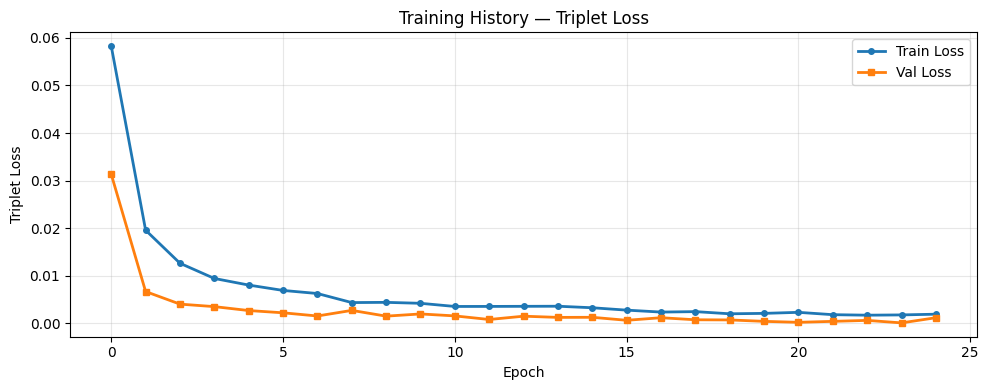

In [19]:
# Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train Loss', linewidth=2, marker='o', markersize=4)
plt.plot(history['val_loss'],   label='Val Loss',   linewidth=2, marker='s', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Triplet Loss')
plt.title('Training History — Triplet Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'training_history.png'), dpi=150)
plt.show()

---
## Section 9 — Load Best Model & Extract Embeddings

In [20]:
# ─── Rebuild the architecture and load the best weights ──────────────────────
# We reuse `build_embedding_network` and `L2Normalize` defined in Section 6.
# Because the architecture uses the serializable L2Normalize layer (not Lambda),
# the saved checkpoint can be reloaded cleanly.

best_model = build_embedding_network(CONFIG['img_size'], CONFIG['embedding_dim'])
best_model.load_weights(checkpoint_path)

print(f'✅ Model weights loaded from: {checkpoint_path}')
print(f'   Input shape : {best_model.input_shape}')
print(f'   Output shape: {best_model.output_shape}')

# Sanity check: verify outputs are L2-normalized (norm should be ≈ 1.0)
test_input  = np.random.rand(1, 224, 224, 3).astype(np.float32)
test_output = best_model.predict(test_input, verbose=0)
norm = np.linalg.norm(test_output)
print(f'   L2 norm (should be ≈1.0): {norm:.6f}')


✅ Model weights loaded from: ./nbis_artifacts_v2/nbis_best_model_v2.keras
   Input shape : (None, 224, 224, 3)
   Output shape: (None, 128)
   L2 norm (should be ≈1.0): 1.000000


In [21]:
def extract_embeddings(
    df: pd.DataFrame,
    model: Model,
    img_size: tuple,
    batch_size: int = 64,
    desc: str = 'Extracting embeddings'
) -> np.ndarray:
    """
    Extract L2-normalized embeddings for all images in a DataFrame.
    Returns array of shape (N, embedding_dim).
    """
    embeddings = []
    paths = df['path'].tolist()

    for i in tqdm(range(0, len(paths), batch_size), desc=desc):
        batch_paths = paths[i: i + batch_size]
        batch_imgs  = np.array(
            [preprocess_image(p, img_size) for p in batch_paths],
            dtype=np.float32
        )
        batch_embs = model.predict(batch_imgs, verbose=0)
        embeddings.append(batch_embs)

    return np.vstack(embeddings).astype(np.float32)


# ─── Extract embeddings for TRAIN / VAL / TEST ──────────────────────────────
#   TRAIN : builds the evaluation FAISS index (Section 11)
#   VAL   : used to pick the operating threshold without touching test (Sec 13)
#   TEST  : final held-out performance (Sec 12) + query set for accuracy tests

print('Extracting embeddings for TRAIN set (used for FAISS eval index)...')
train_embeddings = extract_embeddings(
    df_train, best_model, CONFIG['img_size'], desc='Train embeddings'
)

print('\nExtracting embeddings for VAL set (used for threshold selection)...')
val_embeddings = extract_embeddings(
    df_val, best_model, CONFIG['img_size'], desc='Val embeddings'
)

print('\nExtracting embeddings for TEST set (used for final reporting)...')
test_embeddings = extract_embeddings(
    df_test, best_model, CONFIG['img_size'], desc='Test embeddings'
)

print(f'\n✅ Train embeddings shape : {train_embeddings.shape}')
print(f'✅ Val   embeddings shape : {val_embeddings.shape}')
print(f'✅ Test  embeddings shape : {test_embeddings.shape}')

norms = np.linalg.norm(train_embeddings[:10], axis=1)
print(f'\nL2 norms (should all be ≈1.0): {norms}')


Extracting embeddings for TRAIN set (used for FAISS eval index)...


Train embeddings: 100%|██████████| 605/605 [03:50<00:00,  2.63it/s]



Extracting embeddings for VAL set (used for threshold selection)...


Val embeddings: 100%|██████████| 130/130 [00:53<00:00,  2.44it/s]



Extracting embeddings for TEST set (used for final reporting)...


Test embeddings: 100%|██████████| 130/130 [00:55<00:00,  2.35it/s]


✅ Train embeddings shape : (38681, 128)
✅ Val   embeddings shape : (8295, 128)
✅ Test  embeddings shape : (8294, 128)

L2 norms (should all be ≈1.0): [1.         1.         0.99999994 1.         1.         1.
 0.99999994 0.99999994 1.         1.        ]


---
## Section 10 — Realistic Egyptian Database

We construct a synthetic but realistic Egyptian database with three relational tables:
- **parents** — Egyptian personal info linked to each subject
- **subjects** — biometric subject records
- **images** — each image linked to subject_id and parent_id
> ℹ️ This section was moved to run **after** training and embedding extraction, because the `df_subjects` / `df_parents` tables it produces are first consumed by the FAISS index in Section 11.


In [22]:
import os
os.makedirs('/content/nbis_database', exist_ok=True)
print('✅ Folder created')

✅ Folder created


In [23]:
import sqlite3
import random
import pandas as pd

# ─── Egyptian Data ────────────────────────────────────────────────────────────
FIRST_NAMES_M = [
    'Mohamed', 'Ahmed', 'Mahmoud', 'Omar', 'Ali', 'Hassan', 'Hussein',
    'Ibrahim', 'Khaled', 'Youssef','Tarek', 'Amr', 'Mostafa', 'Karim',
    'Marwan', 'Sherif', 'Hany', 'Wael', 'Ramy', 'Samir', 'Adel', 'Walid',
    'Tamer', 'Ashraf', 'Essam', 'Magdy', 'Nader', 'Osama', 'Hazem', 'Fady'
]
FIRST_NAMES_F = [
    'Fatima', 'Nour', 'Sara', 'Mariam', 'Aya', 'Hana', 'Rania', 'Dina',
    'Laila', 'Yasmin', 'Amira', 'Rana', 'Maha', 'Nada', 'Rahma',
    'Haneen', 'Sana', 'Reem', 'Heba', 'Noha', 'Eman', 'Ghada', 'Mona',
    'Nevine', 'Sherine', 'Doaa', 'Asmaa', 'Samar', 'Rasha', 'Ola'
]
LAST_NAMES = [
    'El-Sayed', 'Hassan', 'Ibrahim', 'Mohamed', 'Ali', 'Ahmed', 'Omar',
    'Mahmoud', 'Khalil', 'Farouk', 'Mansour', 'Gamal', 'El-Naggar',
    'Abdel-Fattah', 'El-Shafei', 'Morsi', 'Saleh', 'Nasser', 'Ramadan',
    'El-Din', 'Badawi', 'Zaki', 'El-Mahdy', 'Ateya', 'Fouad', 'Shawky',
    'El-Masry', 'Abdallah', 'El-Wakil', 'Hegazy', 'El-Sharkawy', 'Badr'
]

# ─── Cities + Hospitals (realistic Egyptian hospitals per city) ───────────────
CITY_HOSPITALS = {
    'Cairo': [
        'Kasr Al-Ainy Hospital',
        'Cairo University Hospital',
        'Al-Galaa Military Hospital',
        'Ain Shams University Hospital',
        'El-Demerdash Hospital',
        'Sayed Galal Hospital',
    ],
    'Giza': [
        'Ahmed Maher Teaching Hospital',
        'El-Haram Hospital',
        'Omm El-Masryeen Hospital',
        'Giza General Hospital',
    ],
    'Alexandria': [
        'Alexandria University Hospital',
        'El-Shatby Maternity Hospital',
        'El-Moassat Hospital',
        'Smouha Medical Center',
    ],
    'Mansoura': [
        'Mansoura University Hospital',
        'Mansoura General Hospital',
        'Zagazig University Hospital',
    ],
    'Tanta': [
        'Tanta University Hospital',
        'Tanta General Hospital',
        'El-Menshawy Hospital',
    ],
    'Aswan': [
        'Aswan University Hospital',
        'Aswan General Hospital',
        'Aswan Military Hospital',
    ],
    'Luxor': [
        'Luxor General Hospital',
        'Luxor International Hospital',
        'South Valley University Hospital',
    ],
    'Asyut': [
        'Asyut University Hospital',
        'Asyut General Hospital',
        'Al-Rajhi Liver Hospital',
    ],
    'Ismailia': [
        'Suez Canal University Hospital',
        'Ismailia General Hospital',
        'El-Nasr Hospital Ismailia',
    ],
    'Port Said': [
        'Port Said General Hospital',
        'Port Fouad Hospital',
        'Canal Teaching Hospital',
    ],
    'Suez': [
        'Suez General Hospital',
        'El-Arbaeen Hospital',
        'Suez Military Hospital',
    ],
    'Zagazig': [
        'Zagazig University Hospital',
        'Zagazig General Hospital',
        'Sharkia Teaching Hospital',
    ],
    'Minya': [
        'Minya University Hospital',
        'Minya General Hospital',
        'El-Minya Teaching Hospital',
    ],
    'Sohag': [
        'Sohag University Hospital',
        'Sohag General Hospital',
        'Sohag Teaching Hospital',
    ],
    'Beni Suef': [
        'Beni Suef University Hospital',
        'Beni Suef General Hospital',
    ],
    'Hurghada': [
        'Hurghada General Hospital',
        'El-Gouna Hospital',
        'Red Sea University Hospital',
    ],
    'Sharm El-Sheikh': [
        'Sharm El-Sheikh International Hospital',
        'South Sinai General Hospital',
    ],
}

CITIES = list(CITY_HOSPITALS.keys())

BLOOD_GROUPS = ['A+', 'A-', 'B+', 'B-', 'AB+', 'AB-', 'O+', 'O-']
CHILD_NAMES  = ['Youssef', 'Omar', 'Adam', 'Ziad', 'Kareem', 'Hamza',
                'Nour', 'Lina', 'Reem', 'Jana', 'Salma', 'Hana']

def make_national_id(gender='M', rng=None):
    if rng is None:
        rng = random.Random()
    year  = str(rng.randint(70, 99)).zfill(2)
    month = str(rng.randint(1, 12)).zfill(2)
    day   = str(rng.randint(1, 28)).zfill(2)
    gov   = str(rng.randint(1, 27)).zfill(2)
    seq   = rng.randint(100, 999)
    if gender == 'M' and seq % 2 == 0:
        seq += 1
    elif gender == 'F' and seq % 2 != 0:
        seq += 1
    check = rng.randint(1, 9)
    return f'2{year}{month}{day}{gov}{seq:03d}0{check}'

def make_phone(rng):
    prefix = rng.choice(['010', '011', '012', '015'])
    return f'+20{prefix[1:]}{rng.randint(10000000, 99999999)}'

def make_email(first, last, rng):
    domain = rng.choice(['gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com'])
    clean  = last.lower().replace('-', '').replace(' ', '')
    return f'{first.lower()}.{clean}{rng.randint(1, 99)}@{domain}'

def make_birth_date(rng, year_range=(1975, 1998)):
    y = rng.randint(*year_range)
    m = rng.randint(1, 12)
    d = rng.randint(1, 28)
    return f'{d:02d}/{m:02d}/{y}'

def make_child_birth_date(rng):
    y = rng.randint(2020, 2025)
    m = rng.randint(1, 12)
    d = rng.randint(1, 28)
    h = rng.randint(0, 23)
    mn= rng.randint(0, 59)
    return f'{d:02d}/{m:02d}/{y} {h:02d}:{mn:02d}'

# ─── Rebuild Database ─────────────────────────────────────────────────────────
db_path = '/content/nbis_database/nbis.db'
conn    = sqlite3.connect(db_path)
cursor  = conn.cursor()

# Drop all tables
cursor.executescript('''
    DROP TABLE IF EXISTS images;
    DROP TABLE IF EXISTS subjects;
    DROP TABLE IF EXISTS fathers;
    DROP TABLE IF EXISTS mothers;
    DROP TABLE IF EXISTS hospitals;
''')

# ── Hospitals table ───────────────────────────────────────────────────────────
cursor.execute('''
    CREATE TABLE hospitals (
        hospital_id   TEXT PRIMARY KEY,
        hospital_name TEXT NOT NULL,
        city          TEXT NOT NULL,
        phone         TEXT,
        address       TEXT
    )
''')

# ── Mothers table ─────────────────────────────────────────────────────────────
cursor.execute('''
    CREATE TABLE mothers (
        mother_id   TEXT PRIMARY KEY,
        full_name   TEXT NOT NULL,
        national_id TEXT UNIQUE NOT NULL,
        birth_date  TEXT,
        blood_group TEXT,
        phone       TEXT,
        email       TEXT,
        city        TEXT,
        hospital_id TEXT,
        FOREIGN KEY (hospital_id) REFERENCES hospitals(hospital_id)
    )
''')

# ── Fathers table ─────────────────────────────────────────────────────────────
cursor.execute('''
    CREATE TABLE fathers (
        father_id   TEXT PRIMARY KEY,
        full_name   TEXT NOT NULL,
        national_id TEXT UNIQUE NOT NULL,
        birth_date  TEXT,
        blood_group TEXT,
        phone       TEXT,
        email       TEXT,
        city        TEXT
    )
''')

# ── Subjects (newborns) table ─────────────────────────────────────────────────
cursor.execute('''
    CREATE TABLE subjects (
        subject_id        TEXT PRIMARY KEY,
        full_name         TEXT NOT NULL,
        gender            TEXT NOT NULL,
        birth_datetime    TEXT,
        blood_group       TEXT,
        weight_kg         TEXT,
        mother_id         TEXT NOT NULL,
        father_id         TEXT NOT NULL,
        hospital_id       TEXT NOT NULL,
        registration_date TEXT,
        FOREIGN KEY (mother_id)   REFERENCES mothers(mother_id),
        FOREIGN KEY (father_id)   REFERENCES fathers(father_id),
        FOREIGN KEY (hospital_id) REFERENCES hospitals(hospital_id)
    )
''')

# ── Images table ──────────────────────────────────────────────────────────────
cursor.execute('''
    CREATE TABLE images (
        image_id   INTEGER PRIMARY KEY AUTOINCREMENT,
        path       TEXT NOT NULL,
        subject_id TEXT NOT NULL,
        gender     TEXT,
        hand       TEXT,
        finger     TEXT,
        FOREIGN KEY (subject_id) REFERENCES subjects(subject_id)
    )
''')

# ─── Insert hospitals ─────────────────────────────────────────────────────────
rng = random.Random(42)
hospital_map = {}  # city → list of hospital_ids

for city, hospitals in CITY_HOSPITALS.items():
    hospital_map[city] = []
    for i, hname in enumerate(hospitals):
        hid   = f'H_{city[:3].upper()}_{i+1:02d}'
        phone = make_phone(rng)
        addr  = f'{rng.randint(1,200)} {rng.choice(["El-Nasr St","El-Tahrir Sq","El-Gomhoria St","El-Horreya Rd"])}, {city}'
        cursor.execute(
            'INSERT INTO hospitals VALUES (?,?,?,?,?)',
            (hid, hname, city, phone, addr)
        )
        hospital_map[city].append(hid)

print(f'✅ Hospitals inserted: {sum(len(v) for v in hospital_map.values())}')

# ─── Insert parents and subjects ──────────────────────────────────────────────
subjects_list = df_all['subject_id'].unique()
rng           = random.Random(42)

for idx, subject_id in enumerate(subjects_list):
    # Subject gender from data
    subj_rows = df_all[df_all['subject_id'] == subject_id]
    gender    = subj_rows['gender'].iloc[0]

    # ── City and hospital (same for both parents and child) ───────────────────
    city        = rng.choice(CITIES)
    hospital_id = rng.choice(hospital_map[city])

    # ── Father ────────────────────────────────────────────────────────────────
    father_id    = f'F{str(idx+1).zfill(4)}'
    father_last  = rng.choice(LAST_NAMES)
    father_first = rng.choice(FIRST_NAMES_M)
    father_name  = f'{father_first} {father_last}'
    cursor.execute('INSERT OR IGNORE INTO fathers VALUES (?,?,?,?,?,?,?,?)', (
        father_id,
        father_name,
        make_national_id('M', rng),
        make_birth_date(rng, (1970, 1990)),
        rng.choice(BLOOD_GROUPS),
        make_phone(rng),
        make_email(father_first, father_last, rng),
        city,
    ))

    # ── Mother ────────────────────────────────────────────────────────────────
    mother_id    = f'M{str(idx+1).zfill(4)}'
    mother_first = rng.choice(FIRST_NAMES_F)
    mother_last  = rng.choice(LAST_NAMES)
    mother_name  = f'{mother_first} {mother_last}'
    cursor.execute('INSERT OR IGNORE INTO mothers VALUES (?,?,?,?,?,?,?,?,?)', (
        mother_id,
        mother_name,
        make_national_id('F', rng),
        make_birth_date(rng, (1975, 1995)),
        rng.choice(BLOOD_GROUPS),
        make_phone(rng),
        make_email(mother_first, mother_last, rng),
        city,
        hospital_id,
    ))

    # ── Child (newborn) ───────────────────────────────────────────────────────
    # Child last name = father's last name (Egyptian tradition)
    child_firsts = FIRST_NAMES_M if gender == 'M' else FIRST_NAMES_F
    child_name   = f'{rng.choice(child_firsts)} {father_first} {father_last}'
    weight       = f'{rng.uniform(2.5, 4.2):.2f} kg'
    birth_dt     = make_child_birth_date(rng)

    cursor.execute('INSERT OR IGNORE INTO subjects VALUES (?,?,?,?,?,?,?,?,?,?)', (
        subject_id,
        child_name,
        gender,
        birth_dt,
        rng.choice(BLOOD_GROUPS),
        weight,
        mother_id,
        father_id,
        hospital_id,
        birth_dt[:10],
    ))

print(f'✅ Subjects inserted : {len(subjects_list)}')
print(f'✅ Fathers inserted  : {len(subjects_list)}')
print(f'✅ Mothers inserted  : {len(subjects_list)}')

# ─── Insert images ────────────────────────────────────────────────────────────
for _, row in df_all.iterrows():
    cursor.execute(
        'INSERT INTO images (path, subject_id, gender, hand, finger) VALUES (?,?,?,?,?)',
        (row['path'], row['subject_id'], row['gender'], row['hand'], row['finger'])
    )

print(f'✅ Images inserted   : {len(df_all)}')

conn.commit()

# ─── Verify with JOIN ─────────────────────────────────────────────────────────
print('\n--- Sample Record ---')
sample_record = pd.read_sql_query('''
    SELECT
        s.subject_id,
        s.full_name    AS child_name,
        s.gender,
        s.birth_datetime,
        s.weight_kg,
        s.blood_group  AS child_blood,
        f.full_name    AS father_name,
        f.national_id  AS father_nid,
        f.phone        AS father_phone,
        m.full_name    AS mother_name,
        m.national_id  AS mother_nid,
        m.phone        AS mother_phone,
        h.hospital_name,
        h.city
    FROM subjects s
    JOIN fathers  f ON s.father_id   = f.father_id
    JOIN mothers  m ON s.mother_id   = m.mother_id
    JOIN hospitals h ON s.hospital_id = h.hospital_id
    LIMIT 5
''', conn)

# ─── Build the in-memory DataFrames that the FAISS indexer (Section 11) needs ─
# `build_faiss_index()` expects:
#   df_subjects with a 'subject_id' column (and, when available, 'parent_id')
#   df_parents  with 'parent_id', 'full_name', 'phone_number', 'email', 'city'
#
# We pick the father as the primary parent contact for identification, and
# surface it as `parent_id`. Change to mother_id if that fits your use case.

df_subjects = pd.read_sql_query(
    'SELECT *, father_id AS parent_id FROM subjects', conn
)
df_parents = pd.read_sql_query(
    """
    SELECT father_id AS parent_id,
           full_name,
           phone  AS phone_number,
           email,
           city
    FROM fathers
    """,
    conn,
)

print(f'✅ df_subjects ready : {len(df_subjects):4d} rows')
print(f'✅ df_parents  ready : {len(df_parents):4d} rows')

conn.close()
display(sample_record)


✅ Hospitals inserted: 54
✅ Subjects inserted : 600
✅ Fathers inserted  : 600
✅ Mothers inserted  : 600
✅ Images inserted   : 55270

--- Sample Record ---
✅ df_subjects ready :  600 rows
✅ df_parents  ready :  600 rows


,subject_id,child_name,gender,birth_datetime,weight_kg,child_blood,father_name,father_nid,father_phone,mother_name,mother_nid,mother_phone,hospital_name,city
0,001,Khaled Ibrahim Nasser,M,03/02/2022 12:06,2.76 kg,AB-,Ibrahim Nasser,27703240479309,+201022575562,Sana Hassan,28704232181809,+201031429110,Mansoura University Hospital,Mansoura
1,002,Ghada Magdy Saleh,F,03/11/2025 19:40,2.95 kg,B+,Magdy Saleh,27112151822707,+201119335534,Dina Ramadan,27204280449005,+201159684848,Sharkia Teaching Hospital,Zagazig
2,003,Mostafa Mostafa Hegazy,M,16/09/2021 02:48,3.12 kg,A+,Mostafa Hegazy,27811231832506,+201263843426,Rania Badawi,27611161375808,+201288461803,Asyut University Hospital,Asyut
3,004,Hany Magdy Mansour,M,25/06/2021 05:34,3.54 kg,A+,Magdy Mansour,29107200349507,+201025374874,Eman Zaki,27305140656401,+201093926371,Mansoura University Hospital,Mansoura
4,005,Adel Omar Hassan,M,04/08/2024 07:14,3.13 kg,A-,Omar Hassan,29906272641504,+201075228535,Reem Khalil,27411161827005,+201151837852,El-Arbaeen Hospital,Suez


---
## Section 11 — FAISS Index Construction

We use `IndexFlatIP` (Inner Product) which equals cosine similarity  
when embeddings are L2-normalized. This gives exact nearest-neighbor search.

In [24]:
def build_faiss_index(
    embeddings: np.ndarray,
    df_ref: pd.DataFrame,
    df_subjects: pd.DataFrame,
    df_parents: pd.DataFrame,
) -> tuple[faiss.Index, list[dict]]:
    """
    Build a FAISS IndexFlatIP over L2-normalized embeddings.
    v2: mapping carries `finger`, `hand`, and `identity_id` so identification
    can match per (subject, finger) — the biometrically correct granularity.
    """
    embs = embeddings.astype(np.float32).copy()
    faiss.normalize_L2(embs)

    dim   = embs.shape[1]
    index = faiss.IndexFlatIP(dim)   # inner-product ≡ cosine on unit vectors
    index.add(embs)

    subj_lookup   = df_subjects.set_index('subject_id').to_dict('index')
    parent_lookup = df_parents .set_index('parent_id' ).to_dict('index')

    mapping = []
    for i, row in df_ref.iterrows():
        sid = row['subject_id']
        pid = row.get('parent_id') or subj_lookup.get(sid, {}).get('parent_id', 'N/A')
        p_info = parent_lookup.get(pid, {})
        mapping.append({
            'faiss_idx'   : len(mapping),
            'subject_id'  : sid,
            'hand'        : row['hand'],
            'finger'      : row['finger'],
            'identity_id' : row['identity_id'],
            'alteration'  : row.get('alteration', 'Real'),
            'parent_id'   : pid,
            'full_name'   : p_info.get('full_name',    'Unknown'),
            'phone'       : p_info.get('phone_number', 'N/A'),
            'email'       : p_info.get('email',        'N/A'),
            'city'        : p_info.get('city',         'N/A'),
        })

    print(f'✅ FAISS index built:')
    print(f'   Vectors in index : {index.ntotal:,}')
    print(f'   Embedding dim    : {dim}')
    print(f'   Index type       : IndexFlatIP (cosine similarity)')
    return index, mapping


# ─── Evaluation index: TRAIN images only (leakage-free for ROC/EER) ─────────
faiss_index, index_mapping = build_faiss_index(
    train_embeddings,
    df_train,
    df_subjects,
    df_parents,
)

print(f'\nSample mapping entry:')
print(json.dumps(index_mapping[0], indent=2, default=str))


✅ FAISS index built:
   Vectors in index : 38,681
   Embedding dim    : 128
   Index type       : IndexFlatIP (cosine similarity)

Sample mapping entry:
{
  "faiss_idx": 0,
  "subject_id": "001",
  "hand": "Left",
  "finger": "index",
  "identity_id": "001_Left_index",
  "alteration": "Altered-Easy",
  "parent_id": "F0001",
  "full_name": "Ibrahim Nasser",
  "phone": "+201022575562",
  "email": "ibrahim.nasser30@yahoo.com",
  "city": "Mansoura"
}


In [25]:
# ─── Section 11.2 — Enrollment / Query split on IDENTITY ────────────────────
# In v2, identity = (subject_id, finger). For each *test* identity we split
# its images into two disjoint halves:
#   • enrollment half → goes into faiss_inference (the "database")
#   • query half      → used to drive the accuracy test (never indexed)
#
# Preference: put Real images in enrollment (matches real-world use where the
# newborn\'s crisp baseline print is the reference), and the degraded Altered
# versions go to query (they simulate noisy future re-scans). If an identity
# lacks Real images, we fall back to a random 50/50 split.
#
# Train and val subjects are fully enrolled (we never query with them).

test_subject_ids = set(df_test['subject_id'].unique())

enroll_rows, query_rows = [], []
rng = random.Random(42)

for ident, grp in df_all.groupby('identity_id'):
    sid = grp['subject_id'].iloc[0]

    if sid in test_subject_ids:
        # Prefer Real-for-enroll, Altered-for-query
        real_mask = grp['alteration'] == 'Real'
        reals     = grp[real_mask]
        altered   = grp[~real_mask]

        if len(reals) >= 1 and len(altered) >= 1:
            enroll_rows.append(reals)
            query_rows .append(altered)
        else:
            # Fallback: random 50/50
            shuf  = grp.sample(frac=1, random_state=42).reset_index(drop=True)
            split = max(1, len(shuf) // 2)
            enroll_rows.append(shuf.iloc[:split])
            query_rows .append(shuf.iloc[split:])
    else:
        # Train / val subjects go fully into enrollment
        enroll_rows.append(grp)

df_enroll = pd.concat(enroll_rows, ignore_index=True)
df_query  = pd.concat(query_rows,  ignore_index=True)

# Leakage guard
overlap = set(df_enroll['path']).intersection(set(df_query['path']))
assert not overlap, f'❌ Leakage: {len(overlap)} shared paths between enroll & query!'

print('✅ Enrollment / query split (identity-level):')
print(f'   Enrollment : {len(df_enroll):6,} images | '
      f'{df_enroll["identity_id"].nunique():5,} identities')
print(f'     breakdown: {df_enroll["alteration"].value_counts().to_dict()}')
print(f'   Query      : {len(df_query):6,} images | '
      f'{df_query ["identity_id"].nunique():5,} identities (test-only)')
print(f'     breakdown: {df_query ["alteration"].value_counts().to_dict()}')
print(f'   Zero path overlap confirmed ✅')

# ─── Embed the enrollment set ───────────────────────────────────────────────
print('\nExtracting embeddings for ENROLLMENT set...')
enroll_embeddings = extract_embeddings(
    df_enroll, best_model, CONFIG['img_size'], desc='Enrollment embeddings'
)
print(f'✅ enroll_embeddings: {enroll_embeddings.shape}')

# ─── Build the inference (deployment) FAISS index ───────────────────────────
faiss_inference, mapping_inference = build_faiss_index(
    enroll_embeddings,
    df_enroll,
    df_subjects,
    df_parents,
)

print(f'\n✅ Two FAISS indexes ready:')
print(f'   Evaluation index : {faiss_index.ntotal:,} vectors (train only)      → Section 12')
print(f'   Inference  index : {faiss_inference.ntotal:,} vectors (enrollment)  → Sections 14–15')


✅ Enrollment / query split (identity-level):
   Enrollment : 47,876 images | 6,000 identities
     breakdown: {'Altered-Easy': 15249, 'Altered-Medium': 14494, 'Altered-Hard': 12133, 'Real': 6000}
   Query      :  7,394 images |   900 identities (test-only)
     breakdown: {'Altered-Easy': 2682, 'Altered-Medium': 2573, 'Altered-Hard': 2139}
   Zero path overlap confirmed ✅

Extracting embeddings for ENROLLMENT set...


Enrollment embeddings: 100%|██████████| 749/749 [04:25<00:00,  2.82it/s]


✅ enroll_embeddings: (47876, 128)
✅ FAISS index built:
   Vectors in index : 47,876
   Embedding dim    : 128
   Index type       : IndexFlatIP (cosine similarity)

✅ Two FAISS indexes ready:
   Evaluation index : 38,681 vectors (train only)      → Section 12
   Inference  index : 47,876 vectors (enrollment)  → Sections 14–15


---
## Section 12 — Evaluation: ROC, AUC, FAR, FRR, EER

Using **TEST subjects only** (never seen during training or FAISS indexing).

In [26]:
def compute_similarity_scores(
    embeddings: np.ndarray,
    df: pd.DataFrame,
    n_impostor_pairs: int = 5000,
    key_col: str = 'identity_id',   # v2: identity = (subject, finger)
    seed: int = 0,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Genuine pair  : two DIFFERENT images that share the same `key_col`
                    (in v2: same subject + same finger — the biometric definition)
    Impostor pair : two images with DIFFERENT `key_col`

    This is the correct formulation for per-finger fingerprint matching.
    """
    embs = embeddings.astype(np.float32).copy()
    faiss.normalize_L2(embs)

    keys        = df[key_col].values
    unique_keys = df[key_col].unique()

    key_to_idx = defaultdict(list)
    for i, k in enumerate(keys):
        key_to_idx[k].append(i)

    genuine_scores, impostor_scores = [], []

    # Genuine: all valid within-identity pairs
    for k in unique_keys:
        idxs = key_to_idx[k]
        if len(idxs) < 2:
            continue
        for i in range(len(idxs)):
            for j in range(i + 1, len(idxs)):
                genuine_scores.append(float(np.dot(embs[idxs[i]], embs[idxs[j]])))

    # Impostor: random pairs with different keys
    rng     = random.Random(seed)
    all_idx = list(range(len(keys)))
    sampled = 0
    while sampled < n_impostor_pairs and len(all_idx) > 1:
        i, j = rng.sample(all_idx, 2)
        if keys[i] != keys[j]:
            impostor_scores.append(float(np.dot(embs[i], embs[j])))
            sampled += 1

    return np.array(genuine_scores), np.array(impostor_scores)


# ─── Compute scores on VAL (for threshold) and TEST (for reporting) ─────────
print('Computing VAL genuine/impostor scores (for threshold selection)...')
val_genuine, val_impostor = compute_similarity_scores(
    val_embeddings, df_val, key_col='identity_id', seed=1,
)
print(f'   VAL  genuine={len(val_genuine):,}  impostor={len(val_impostor):,}')
print(f'   VAL  genuine  mean ± std: {val_genuine.mean():.4f} ± {val_genuine.std():.4f}')
print(f'   VAL  impostor mean ± std: {val_impostor.mean():.4f} ± {val_impostor.std():.4f}')

# d-prime on val (diagnostic)
d_prime_val = (val_genuine.mean() - val_impostor.mean()) / \
              np.sqrt((val_genuine.std()**2 + val_impostor.std()**2) / 2)
print(f'   VAL  d-prime  : {d_prime_val:.3f}   (>3 is production-quality)')

print('\nComputing TEST genuine/impostor scores (for final reporting)...')
genuine_scores, impostor_scores = compute_similarity_scores(
    test_embeddings, df_test, key_col='identity_id', seed=2,
)
print(f'   TEST genuine={len(genuine_scores):,}  impostor={len(impostor_scores):,}')
print(f'   TEST genuine  mean ± std: {genuine_scores.mean():.4f} ± {genuine_scores.std():.4f}')
print(f'   TEST impostor mean ± std: {impostor_scores.mean():.4f} ± {impostor_scores.std():.4f}')

d_prime_test = (genuine_scores.mean() - impostor_scores.mean()) / \
               np.sqrt((genuine_scores.std()**2 + impostor_scores.std()**2) / 2)
print(f'   TEST d-prime  : {d_prime_test:.3f}')


Computing VAL genuine/impostor scores (for threshold selection)...
   VAL  genuine=34,644  impostor=5,000
   VAL  genuine  mean ± std: 0.9511 ± 0.0372
   VAL  impostor mean ± std: 0.0330 ± 0.2397
   VAL  d-prime  : 5.352   (>3 is production-quality)

Computing TEST genuine/impostor scores (for final reporting)...
   TEST genuine=34,638  impostor=5,000
   TEST genuine  mean ± std: 0.9509 ± 0.0370
   TEST impostor mean ± std: 0.0428 ± 0.2417
   TEST d-prime  : 5.251


In [27]:
def compute_roc_metrics(
    genuine_scores: np.ndarray,
    impostor_scores: np.ndarray,
    label: str = '',
) -> dict:
    """
    Compute ROC curve, AUC, FAR, FRR, and EER for a pair of score arrays.

    Returns dict with: fpr, tpr, thresholds, auc, far, frr, eer, eer_threshold
    """
    y_true   = np.concatenate([np.ones(len(genuine_scores)),
                               np.zeros(len(impostor_scores))])
    y_scores = np.concatenate([genuine_scores, impostor_scores])

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    far = fpr
    frr = 1 - tpr

    eer_idx       = np.argmin(np.abs(far - frr))
    eer           = (far[eer_idx] + frr[eer_idx]) / 2
    eer_threshold = thresholds[eer_idx]

    print('─' * 55)
    print(f'📊 Biometric Performance Metrics{(" — " + label) if label else ""}')
    print('─' * 55)
    print(f'  ROC-AUC       : {roc_auc:.4f}')
    print(f'  EER           : {eer * 100:.2f}%')
    print(f'  EER Threshold : {eer_threshold:.4f}')
    print(f'  FAR @ EER     : {far[eer_idx] * 100:.2f}%')
    print(f'  FRR @ EER     : {frr[eer_idx] * 100:.2f}%')
    print('─' * 55)

    return {
        'fpr'          : fpr,
        'tpr'          : tpr,
        'thresholds'   : thresholds,
        'auc'          : roc_auc,
        'far'          : far,
        'frr'          : frr,
        'eer'          : eer,
        'eer_threshold': eer_threshold,
    }


# ─── Threshold selection on VAL — then frozen ───────────────────────────────
# Picking the threshold on TEST would be a form of test-set contamination
# (selection leakage). We pick it on VAL, freeze it, and then just *report*
# how it performs on TEST.

val_metrics = compute_roc_metrics(val_genuine, val_impostor, label='VAL')

print()
metrics     = compute_roc_metrics(genuine_scores, impostor_scores, label='TEST')

# The operating threshold used EVERYWHERE downstream is the VAL-EER threshold.
OPTIMAL_THRESHOLD = float(val_metrics['eer_threshold'])

print('\n' + '═' * 60)
print('  Deployment threshold = VAL-EER threshold (frozen)')
print('═' * 60)
print(f'  OPTIMAL_THRESHOLD     : {OPTIMAL_THRESHOLD:.6f}')
print(f'  VAL  EER  / AUC       : {val_metrics["eer"]*100:.2f}%  / {val_metrics["auc"]:.4f}')
print(f'  TEST EER  / AUC       : {metrics["eer"]*100:.2f}%  / {metrics["auc"]:.4f}')
print('═' * 60)


───────────────────────────────────────────────────────
📊 Biometric Performance Metrics — VAL
───────────────────────────────────────────────────────
  ROC-AUC       : 1.0000
  EER           : 0.16%
  EER Threshold : 0.7474
  FAR @ EER     : 0.16%
  FRR @ EER     : 0.15%
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
📊 Biometric Performance Metrics — TEST
───────────────────────────────────────────────────────
  ROC-AUC       : 1.0000
  EER           : 0.10%
  EER Threshold : 0.7317
  FAR @ EER     : 0.10%
  FRR @ EER     : 0.09%
───────────────────────────────────────────────────────

════════════════════════════════════════════════════════════
  Deployment threshold = VAL-EER threshold (frozen)
════════════════════════════════════════════════════════════
  OPTIMAL_THRESHOLD     : 0.747435
  VAL  EER  / AUC       : 0.16%  / 1.0000
  TEST EER  / AUC       : 0.10%  / 1.0000
════════════════════════════════════════════════

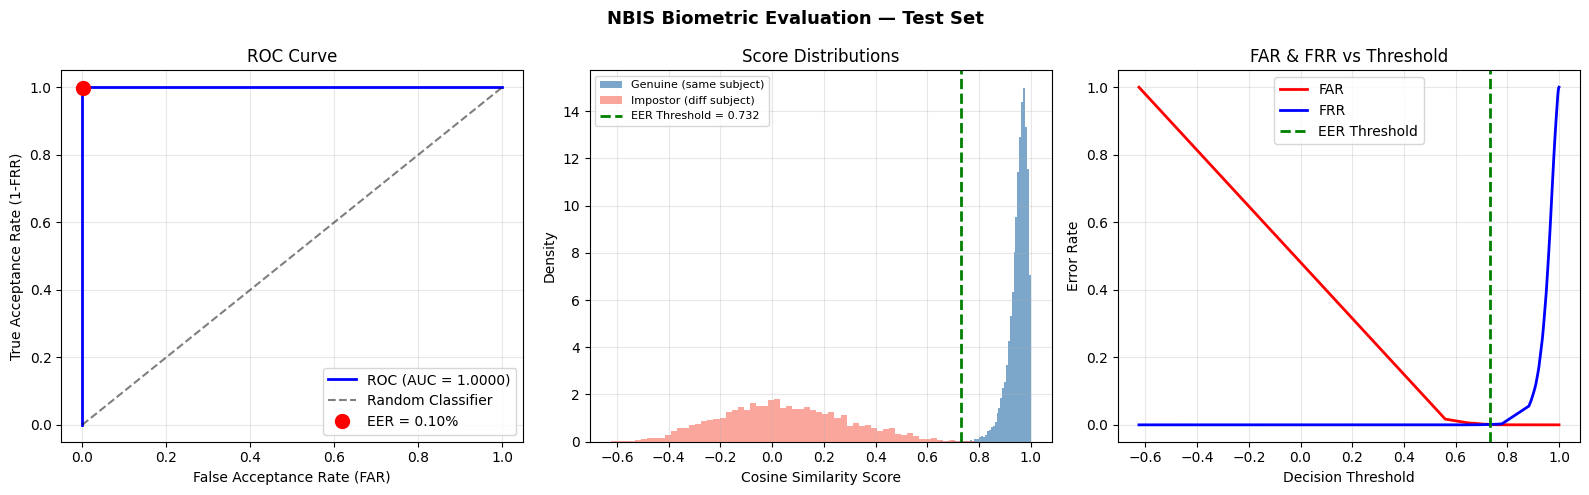

In [28]:
def plot_evaluation(metrics: dict, genuine_scores: np.ndarray, impostor_scores: np.ndarray):
    """Plot ROC curve and score distribution histograms."""
    fig = plt.figure(figsize=(16, 5))
    gs  = gridspec.GridSpec(1, 3, figure=fig)

    # ── ROC Curve ──────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(metrics['fpr'], metrics['tpr'], 'b-', linewidth=2,
             label=f'ROC (AUC = {metrics["auc"]:.4f})')
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
    eer_idx = np.argmin(np.abs(metrics['far'] - metrics['frr']))
    ax1.plot(metrics['fpr'][eer_idx], metrics['tpr'][eer_idx],
             'ro', markersize=10, label=f'EER = {metrics["eer"]*100:.2f}%')
    ax1.set_xlabel('False Acceptance Rate (FAR)')
    ax1.set_ylabel('True Acceptance Rate (1-FRR)')
    ax1.set_title('ROC Curve')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)

    # ── Score Distribution ─────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    ax2.hist(genuine_scores,  bins=60, alpha=0.7, color='steelblue',
             label='Genuine (same subject)',  density=True)
    ax2.hist(impostor_scores, bins=60, alpha=0.7, color='salmon',
             label='Impostor (diff subject)', density=True)
    ax2.axvline(metrics['eer_threshold'], color='green', linestyle='--',
                linewidth=2, label=f'EER Threshold = {metrics["eer_threshold"]:.3f}')
    ax2.set_xlabel('Cosine Similarity Score')
    ax2.set_ylabel('Density')
    ax2.set_title('Score Distributions')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # ── FAR / FRR vs Threshold ─────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[2])
    thresh_plot = metrics['thresholds']
    ax3.plot(thresh_plot, metrics['far'], 'r-', linewidth=2, label='FAR')
    ax3.plot(thresh_plot, metrics['frr'], 'b-', linewidth=2, label='FRR')
    ax3.axvline(metrics['eer_threshold'], color='green', linestyle='--',
                linewidth=2, label=f'EER Threshold')
    ax3.set_xlabel('Decision Threshold')
    ax3.set_ylabel('Error Rate')
    ax3.set_title('FAR & FRR vs Threshold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    fig.suptitle('NBIS Biometric Evaluation — Test Set', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_dir'], 'evaluation_metrics.png'), dpi=150)
    plt.show()


plot_evaluation(metrics, genuine_scores, impostor_scores)

---
## Section 13 — Threshold Selection (on VAL, never on TEST)

The operating threshold is set at the **Equal Error Rate (EER)** point
computed on the **validation set** (where FAR = FRR). It is then **frozen**
— the test set is never used to pick or tune this value.

Selecting the threshold on the test set would be a form of *selection
leakage*: the reported test EER would no longer reflect performance on truly
unseen data. Keeping threshold selection on VAL is the standard protocol for
biometric benchmarks.

`OPTIMAL_THRESHOLD` is what every downstream inference call (Sections 14–15)
uses.


In [29]:
# ─── Final threshold summary (val-derived, applied on test) ─────────────────
print('═' * 60)
print('  NBIS — Deployment Threshold Summary')
print('═' * 60)
print(f'  Threshold (EER on VAL): {OPTIMAL_THRESHOLD:.6f}   ← frozen, deployed')
print('  ─────────────────────────────────────────────')
print(f'  VAL  EER              : {val_metrics["eer"] * 100:.2f}%')
print(f'  VAL  AUC              : {val_metrics["auc"]:.4f}')
print('  ─────────────────────────────────────────────')
print(f'  TEST EER              : {metrics["eer"] * 100:.2f}%   ← held-out report')
print(f'  TEST AUC              : {metrics["auc"]:.4f}')
print(f'  TEST FAR @ threshold  : '
      f'{metrics["far"][np.argmin(np.abs(metrics["far"] - metrics["frr"]))] * 100:.2f}%')
print(f'  TEST FRR @ threshold  : '
      f'{metrics["frr"][np.argmin(np.abs(metrics["far"] - metrics["frr"]))] * 100:.2f}%')
print('═' * 60)
print('  Note: threshold is NOT retuned on test — it is frozen on val.')
print('═' * 60)


════════════════════════════════════════════════════════════
  NBIS — Deployment Threshold Summary
════════════════════════════════════════════════════════════
  Threshold (EER on VAL): 0.747435   ← frozen, deployed
  ─────────────────────────────────────────────
  VAL  EER              : 0.16%
  VAL  AUC              : 1.0000
  ─────────────────────────────────────────────
  TEST EER              : 0.10%   ← held-out report
  TEST AUC              : 1.0000
  TEST FAR @ threshold  : 0.10%
  TEST FRR @ threshold  : 0.09%
════════════════════════════════════════════════════════════
  Note: threshold is NOT retuned on test — it is frozen on val.
════════════════════════════════════════════════════════════


---
## Section 14 — Inference Function (FAISS-based)

Given a new fingerprint image, the system:
1. Preprocesses the image
2. Computes the embedding via the trained model
3. L2-normalizes the embedding
4. Searches the FAISS index for the top-k nearest neighbors
5. Returns subject info, parent info, and similarity score

In [30]:
def identify_fingerprint(
    image_path: str,
    model: Model,
    index: faiss.Index,
    mapping: list[dict],
    threshold: float,
    img_size: tuple = (224, 224),
    top_k: int = 3,
) -> dict:
    """
    v2: identify a fingerprint image and return subject + finger + parent info.

    The match key is (subject_id, finger) — returned as `identity_id`.
    Accuracy tests compare on this, not just subject_id.
    """
    # 1. Preprocess
    img_arr   = preprocess_image(image_path, img_size)
    img_batch = np.expand_dims(img_arr, 0).astype(np.float32)

    # 2. Embed + L2 normalize
    embedding = model.predict(img_batch, verbose=0)
    emb_norm  = embedding.astype(np.float32).copy()
    faiss.normalize_L2(emb_norm)

    # 3. FAISS search
    scores, indices = index.search(emb_norm, top_k)
    top_score = float(scores[0][0])
    top_idx   = int(indices[0][0])

    if top_score >= threshold:
        match = mapping[top_idx]
        result = {
            'status'        : 'MATCH',
            'confidence'    : f'{top_score * 100:.2f}%',
            # Identity (v2: subject + finger)
            'subject_id'    : match['subject_id'],
            'hand'          : match['hand'],
            'finger'        : match['finger'],
            'identity_id'   : match['identity_id'],
            # Parent linkage
            'parent_id'     : match['parent_id'],
            'parent_name'   : match['full_name'],
            'parent_phone'  : match['phone'],
            'parent_email'  : match['email'],
            'city'          : match['city'],
            # Numeric
            'similarity'    : top_score,
            'threshold_used': threshold,
            'top_k_results' : [
                {
                    'rank'       : r + 1,
                    'subject_id' : mapping[int(indices[0][r])]['subject_id'],
                    'finger'     : mapping[int(indices[0][r])]['finger'],
                    'identity_id': mapping[int(indices[0][r])]['identity_id'],
                    'score'      : float(scores[0][r]),
                }
                for r in range(min(top_k, len(scores[0])))
            ]
        }
    else:
        result = {
            'status'        : 'NO MATCH',
            'confidence'    : f'{top_score * 100:.2f}%',
            'subject_id'    : None,
            'identity_id'   : None,
            'similarity'    : top_score,
            'threshold_used': threshold,
            'message'       : 'Similarity below threshold. Identity could not be verified.',
        }
    return result


print('✅ identify_fingerprint (v2) defined — returns (subject, finger) identity.')


✅ identify_fingerprint (v2) defined — returns (subject, finger) identity.


## Testing The Model

In [31]:
# ─── Demo: identify ONE query image (guaranteed not in enrollment index) ────
test_sample     = df_query.sample(1, random_state=99).iloc[0]
test_image_path = test_sample['path']

print(f'Query image     : {test_image_path}')
print(f'True identity   : subject={test_sample["subject_id"]} '
      f'hand={test_sample["hand"]} finger={test_sample["finger"]}')
print(f'                  (alteration: {test_sample["alteration"]})')
print('(This image is in df_query, NOT in the enrollment index.)')

result = identify_fingerprint(
    image_path = test_image_path,
    model      = best_model,
    index      = faiss_inference,
    mapping    = mapping_inference,
    threshold  = OPTIMAL_THRESHOLD,
    img_size   = CONFIG['img_size'],
    top_k      = 5,
)

print('\n' + '=' * 55)
print('  IDENTIFICATION RESULT')
print('=' * 55)
for k, v in result.items():
    if k != 'top_k_results':
        print(f'  {k:<16}: {v}')
print('\n  Top-K matches:')
for r in result.get('top_k_results', []):
    match_flag = '✓' if r['identity_id'] == test_sample['identity_id'] else ' '
    print(f'    {match_flag}  Rank {r["rank"]}: '
          f'subject={r["subject_id"]} finger={r["finger"]:7s}  score={r["score"]:.4f}')
print('=' * 55)


Query image     : /content/SOCOFing/Altered/Altered-Hard/527__M_Right_thumb_finger_CR.BMP
True identity   : subject=527 hand=Right finger=thumb
                  (alteration: Altered-Hard)
(This image is in df_query, NOT in the enrollment index.)

  IDENTIFICATION RESULT
  status          : MATCH
  confidence      : 87.74%
  subject_id      : 395
  hand            : Right
  finger          : thumb
  identity_id     : 395_Right_thumb
  parent_id       : F0395
  parent_name     : Mahmoud Farouk
  parent_phone    : +201527898844
  parent_email    : mahmoud.farouk28@outlook.com
  city            : Zagazig
  similarity      : 0.8774045705795288
  threshold_used  : 0.7474350929260254

  Top-K matches:
       Rank 1: subject=395 finger=thumb    score=0.8774
    ✓  Rank 2: subject=527 finger=thumb    score=0.8763
       Rank 3: subject=395 finger=thumb    score=0.8638
       Rank 4: subject=395 finger=thumb    score=0.8544
       Rank 5: subject=395 finger=thumb    score=0.8403


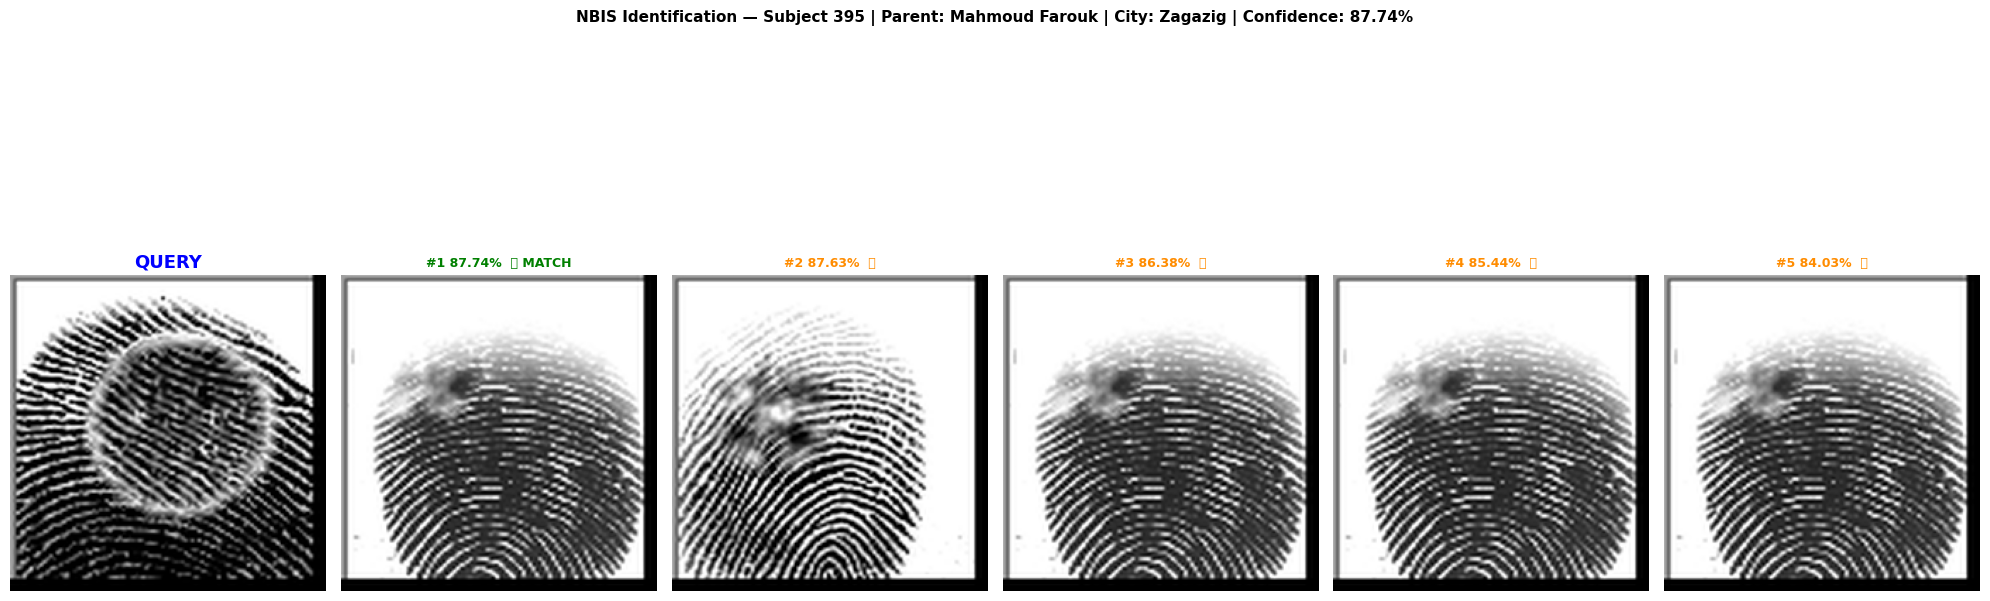

✅ Saved: ./nbis_artifacts_v2/identification_result.png


In [32]:
def visualize_identification_result(
    query_path: str,
    result: dict,
    mapping: list[dict],
    img_size: tuple,
    top_k: int = 5
):
    """
    Visualize query fingerprint alongside top-K matches with full parent info.
    """
    top_k_results = result.get('top_k_results', [])

    fig = plt.figure(figsize=(20, 8))
    gs  = gridspec.GridSpec(1, top_k + 1, figure=fig)

    # ── Query image ───────────────────────────────────────────────────────────
    ax_query = fig.add_subplot(gs[0])
    query_img = preprocess_image(query_path, img_size)
    ax_query.imshow(query_img[:, :, 0], cmap='gray')
    ax_query.set_title('QUERY', fontweight='bold', fontsize=13, color='blue')
    ax_query.axis('off')

    # Query info box below
    query_info = (
        f"Path: {query_path.split('/')[-1]}\n"
        f"True Subject: {result['subject_id']}"
    )
    ax_query.set_xlabel(query_info, fontsize=8, color='blue',
                        labelpad=10, ha='center')

    for spine in ax_query.spines.values():
        spine.set_edgecolor('blue')
        spine.set_linewidth(3)

    # ── Top-K matches ─────────────────────────────────────────────────────────
    for rank_idx, rank_result in enumerate(top_k_results):
        subject_id = rank_result['subject_id']
        score      = rank_result['score']

        # Find image for this subject
        subj_rows  = df_all[df_all['subject_id'] == subject_id]
        if len(subj_rows) == 0:
            continue
        match_path = subj_rows.iloc[0]['path']
        match_img  = preprocess_image(match_path, img_size)

        # Get parent info from mapping
        parent_info = next(
            (m for m in mapping if m['subject_id'] == subject_id), {}
        )

        # Get child info from df_subjects
        child_info  = df_subjects[
            df_subjects['subject_id'] == subject_id
        ]
        child_name  = child_info.iloc[0]['full_name'] if len(child_info) > 0 else 'N/A'
        child_gender= child_info.iloc[0]['gender']    if len(child_info) > 0 else 'N/A'

        color  = 'green' if rank_idx == 0 else 'darkorange'
        label  = f'#{rank_idx+1} {score*100:.2f}%  {"✅ MATCH" if rank_idx==0 else "❌"}'

        ax = fig.add_subplot(gs[rank_idx + 1])
        ax.imshow(match_img[:, :, 0], cmap='gray')
        ax.set_title(label, fontweight='bold', fontsize=9, color=color)
        ax.axis('off')

        # Full info box
        info_text = (
            f"✅ MATCH\n"
            f"Sub:{subject_id}  {subj_rows.iloc[0]['hand']} {subj_rows.iloc[0]['finger']}\n"
            f"Child : {child_name} ({child_gender})\n"
            f"Parent: {parent_info.get('full_name',  'N/A')}\n"
            f"NID   : {parent_info.get('national_id','N/A')}\n"
            f"Phone : {parent_info.get('phone',      'N/A')}\n"
            f"Email : {parent_info.get('email',      'N/A')}\n"
            f"City  : {parent_info.get('city',       'N/A')}"
        ) if rank_idx == 0 else (
            f"Sub:{subject_id}  {subj_rows.iloc[0]['hand']} {subj_rows.iloc[0]['finger']}\n"
            f"Child : {child_name} ({child_gender})\n"
            f"Parent: {parent_info.get('full_name',  'N/A')}\n"
            f"NID   : {parent_info.get('national_id','N/A')}\n"
            f"Phone : {parent_info.get('phone',      'N/A')}\n"
            f"Email : {parent_info.get('email',      'N/A')}\n"
            f"City  : {parent_info.get('city',       'N/A')}"
        )

        ax.set_xlabel(info_text, fontsize=7, color=color,
                      labelpad=10, ha='center', linespacing=1.6)

        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)

    fig.suptitle(
        f'NBIS Identification — Subject {result["subject_id"]} | '
        f'Parent: {result["parent_name"]} | '
        f'City: {result["city"]} | '
        f'Confidence: {result["confidence"]}',
        fontsize=11, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig(
        os.path.join(CONFIG['output_dir'], 'identification_result.png'),
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f'✅ Saved: {CONFIG["output_dir"]}/identification_result.png')


# ─── Run ──────────────────────────────────────────────────────────────────────
visualize_identification_result(
    query_path = test_image_path,
    result     = result,
    mapping    = mapping_inference,
    img_size   = CONFIG['img_size'],
    top_k      = 5
)


In [33]:
# ─── Quick Rank-1 accuracy on 20 QUERY images — matching on IDENTITY ────────
correct, incorrect = 0, 0
results = []

sample_n     = min(20, len(df_query))
test_samples = df_query.sample(sample_n, random_state=42)

for _, row in test_samples.iterrows():
    r = identify_fingerprint(
        image_path = row['path'],
        model      = best_model,
        index      = faiss_inference,
        mapping    = mapping_inference,
        threshold  = OPTIMAL_THRESHOLD,
        img_size   = CONFIG['img_size'],
        top_k      = 5,
    )
    true_identity = row['identity_id']
    pred_identity = r.get('identity_id')
    is_correct    = (pred_identity == true_identity)

    correct   += int(is_correct)
    incorrect += int(not is_correct)
    results.append({
        'true_id'    : true_identity,
        'pred_id'    : pred_identity,
        'alteration' : row['alteration'],
        'ok'         : '✅' if is_correct else '❌',
        'confidence' : r.get('confidence', 'N/A'),
    })

print('=' * 70)
print(f'  Quick Rank-1 Test — {sample_n} QUERY images (matching on subject+finger)')
print('=' * 70)
for r in results:
    print(f"  {r['ok']}  true={r['true_id']:<20s} "
          f"pred={str(r['pred_id']):<20s} [{r['alteration']:<14s}] {r['confidence']}")
print('=' * 70)
acc = correct / sample_n * 100
print(f'  Correct   : {correct}/{sample_n}  ({acc:.1f}%)')
print(f'  Incorrect : {incorrect}/{sample_n}  ({100-acc:.1f}%)')
print('=' * 70)


  Quick Rank-1 Test — 20 QUERY images (matching on subject+finger)
  ✅  true=484_Right_thumb      pred=484_Right_thumb      [Altered-Easy  ] 99.39%
  ❌  true=484_Left_ring        pred=484_Left_middle      [Altered-Medium] 93.86%
  ✅  true=519_Right_little     pred=519_Right_little     [Altered-Easy  ] 97.16%
  ✅  true=302_Left_middle      pred=302_Left_middle      [Altered-Medium] 96.68%
  ✅  true=586_Left_little      pred=586_Left_little      [Altered-Medium] 96.73%
  ✅  true=404_Left_thumb       pred=404_Left_thumb       [Altered-Medium] 98.50%
  ✅  true=529_Right_thumb      pred=529_Right_thumb      [Altered-Medium] 94.76%
  ✅  true=503_Right_little     pred=503_Right_little     [Altered-Easy  ] 99.59%
  ✅  true=288_Right_thumb      pred=288_Right_thumb      [Altered-Medium] 93.47%
  ✅  true=043_Left_little      pred=043_Left_little      [Altered-Easy  ] 98.20%
  ✅  true=485_Right_thumb      pred=485_Right_thumb      [Altered-Hard  ] 97.02%
  ✅  true=578_Right_middle     pred=578_Ri

---
## Section 15 — Embedding Distance Visualization

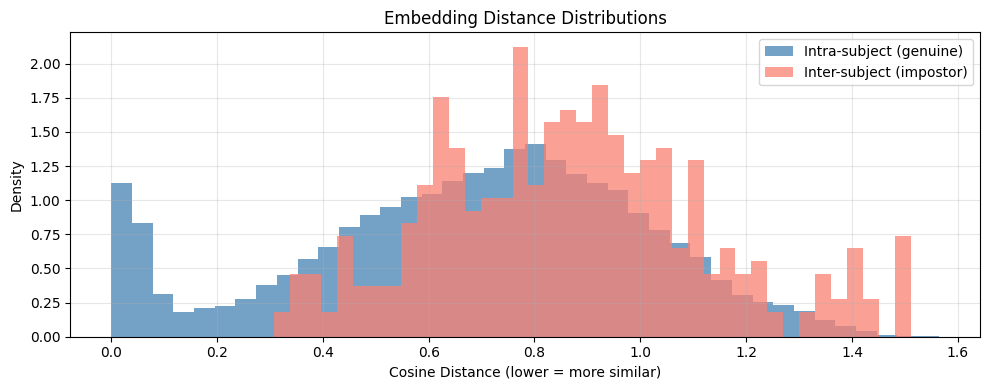

In [34]:
def visualize_embedding_distances(test_embeddings, df_test, n_subjects=10):
    """
    Visualize intra-subject vs inter-subject cosine distance distributions
    for a subset of test subjects.
    """
    embs = test_embeddings.astype(np.float32).copy()
    faiss.normalize_L2(embs)

    subject_ids   = df_test['subject_id'].values
    unique_subjs  = df_test['subject_id'].unique()[:n_subjects]

    subj_to_idx = defaultdict(list)
    for i, sid in enumerate(subject_ids):
        subj_to_idx[sid].append(i)

    intra_dists = []
    inter_dists = []

    for sid in unique_subjs:
        idxs = subj_to_idx[sid]
        for i in range(len(idxs)):
            for j in range(i+1, len(idxs)):
                sim = np.dot(embs[idxs[i]], embs[idxs[j]])
                intra_dists.append(1 - sim)

        other_subjs = [s for s in unique_subjs if s != sid]
        for osid in random.sample(list(other_subjs), min(3, len(other_subjs))):
            for oi in subj_to_idx[osid][:2]:
                for ai in idxs[:2]:
                    sim = np.dot(embs[ai], embs[oi])
                    inter_dists.append(1 - sim)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(intra_dists, bins=40, alpha=0.75, color='steelblue',
            label='Intra-subject (genuine)', density=True)
    ax.hist(inter_dists, bins=40, alpha=0.75, color='salmon',
            label='Inter-subject (impostor)', density=True)
    ax.set_xlabel('Cosine Distance (lower = more similar)')
    ax.set_ylabel('Density')
    ax.set_title('Embedding Distance Distributions')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_dir'], 'embedding_distances.png'), dpi=150)
    plt.show()


# ← updated: use more subjects for richer visualization
visualize_embedding_distances(test_embeddings, df_test, n_subjects=30)

In [35]:
# ─── Full Rank-1 identification accuracy on ALL query images ────────────────
# Match criterion: identity_id (subject + hand + finger).
# We also break down accuracy by alteration type so you can see which kinds
# of degradations the model handles well.

correct   = 0
incorrect = 0
per_alt   = defaultdict(lambda: {'correct': 0, 'total': 0})
per_finger= defaultdict(lambda: {'correct': 0, 'total': 0})

n_query = len(df_query)
print(f'Running identification on all {n_query:,} QUERY images...')
print('(Each query image is guaranteed NOT to be in the enrollment index.)')

for _, row in tqdm(df_query.iterrows(), total=n_query):
    r = identify_fingerprint(
        image_path = row['path'],
        model      = best_model,
        index      = faiss_inference,
        mapping    = mapping_inference,
        threshold  = OPTIMAL_THRESHOLD,
        img_size   = CONFIG['img_size'],
        top_k      = 1,
    )
    true_identity = row['identity_id']
    pred_identity = r.get('identity_id')
    is_correct    = (pred_identity == true_identity)

    correct   += int(is_correct)
    incorrect += int(not is_correct)

    alt    = row['alteration']
    finger = row['finger']
    per_alt   [alt]   ['total'] += 1
    per_alt   [alt]   ['correct'] += int(is_correct)
    per_finger[finger]['total'] += 1
    per_finger[finger]['correct'] += int(is_correct)

acc = correct / n_query * 100
print('\n' + '=' * 70)
print(f'  Full Rank-1 Accuracy — {n_query:,} query images')
print('=' * 70)
print(f'  Correct   : {correct:5d}/{n_query} ({acc:.2f}%)')
print(f'  Incorrect : {incorrect:5d}/{n_query} ({100-acc:.2f}%)')
print('─' * 70)
print('  Per alteration type:')
for alt, c in sorted(per_alt.items()):
    a = c['correct'] / c['total'] * 100 if c['total'] else 0
    print(f'    {alt:18s}: {c["correct"]:5d}/{c["total"]:<5d}  ({a:5.2f}%)')
print('─' * 70)
print('  Per finger type:')
for finger, c in sorted(per_finger.items()):
    a = c['correct'] / c['total'] * 100 if c['total'] else 0
    print(f'    {finger:10s}: {c["correct"]:5d}/{c["total"]:<5d}  ({a:5.2f}%)')
print('=' * 70)


Running identification on all 7,394 QUERY images...
(Each query image is guaranteed NOT to be in the enrollment index.)


100%|██████████| 7394/7394 [11:57<00:00, 10.31it/s]


  Full Rank-1 Accuracy — 7,394 query images
  Correct   :  7300/7394 (98.73%)
  Incorrect :    94/7394 (1.27%)
──────────────────────────────────────────────────────────────────────
  Per alteration type:
    Altered-Easy      :  2670/2682   (99.55%)
    Altered-Hard      :  2085/2139   (97.48%)
    Altered-Medium    :  2545/2573   (98.91%)
──────────────────────────────────────────────────────────────────────
  Per finger type:
    index     :  1435/1444   (99.38%)
    little    :  1431/1480   (96.69%)
    middle    :  1455/1461   (99.59%)
    ring      :  1480/1491   (99.26%)
    thumb     :  1499/1518   (98.75%)


---
## Section 15.5 — Diagnostic Analysis (v2)

Three numbers that every biometric thesis committee asks about:

1. **d-prime (d′)** — how many standard deviations apart are genuine and
   impostor distributions? Commercial fingerprint systems achieve d′ ≥ 5.
   d′ ≥ 3 is "decent". d′ < 2 means the embedding space isn\'t discriminating.

2. **Per-alteration accuracy** — Real vs Altered-Easy vs Altered-Medium vs
   Altered-Hard. Expect a monotone drop: Real ≳ Easy > Medium > Hard.
   If it\'s flat, the model didn\'t really learn to handle degradation.

3. **Per-finger breakdown** — thumbs are typically the easiest (largest area,
   clearest ridges), little fingers the hardest. A healthy model shows this
   ordering.


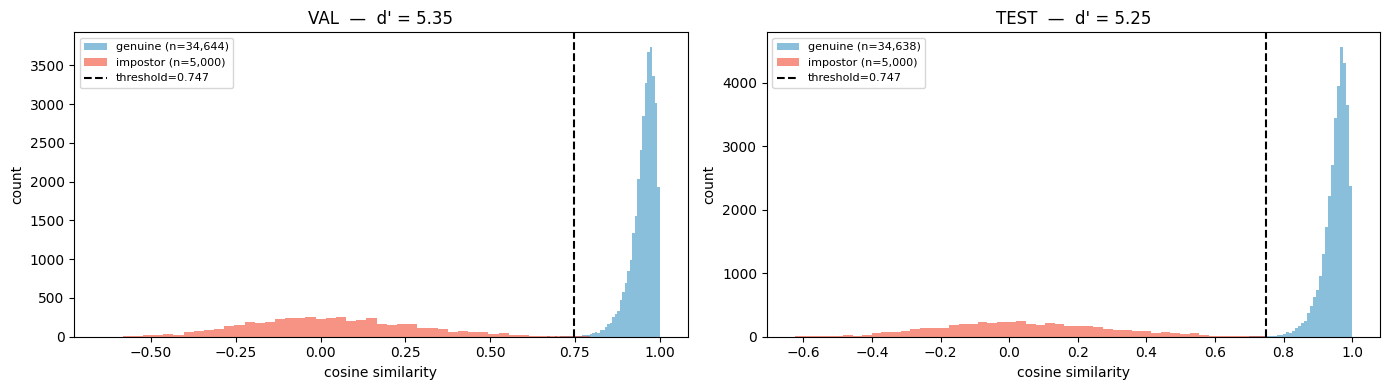

  Diagnostic Summary (v2)
  d-prime (VAL)  : 5.352
  d-prime (TEST) : 5.251
  Interpretation :
    Excellent — production-grade separation.
────────────────────────────────────────────────────────────
  VAL  AUC / EER : 1.0000  /  0.16%
  TEST AUC / EER : 1.0000  /  0.10%


In [36]:
# ─── d-prime (distribution separation) ───────────────────────────────────────
def d_prime(gen, imp):
    return (gen.mean() - imp.mean()) / np.sqrt((gen.std()**2 + imp.std()**2) / 2)

d_val  = d_prime(val_genuine,     val_impostor)
d_test = d_prime(genuine_scores,  impostor_scores)

# ─── Visual: genuine/impostor histograms side-by-side (val vs test) ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (gen, imp, label, dp) in zip(axes, [
    (val_genuine,    val_impostor,    'VAL',  d_val),
    (genuine_scores, impostor_scores, 'TEST', d_test),
]):
    ax.hist(gen, bins=50, alpha=0.55, label=f'genuine (n={len(gen):,})', color='#2b8cbe')
    ax.hist(imp, bins=50, alpha=0.55, label=f'impostor (n={len(imp):,})', color='#f03b20')
    ax.axvline(OPTIMAL_THRESHOLD, color='black', ls='--', lw=1.5,
               label=f'threshold={OPTIMAL_THRESHOLD:.3f}')
    ax.set_title(f'{label}  —  d\' = {dp:.2f}')
    ax.set_xlabel('cosine similarity')
    ax.set_ylabel('count')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'diagnostic_d_prime.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# ─── Text summary ────────────────────────────────────────────────────────────
print('=' * 60)
print('  Diagnostic Summary (v2)')
print('=' * 60)
print(f'  d-prime (VAL)  : {d_val:.3f}')
print(f'  d-prime (TEST) : {d_test:.3f}')
print('  Interpretation :')
if d_test >= 5:
    print('    Excellent — production-grade separation.')
elif d_test >= 3:
    print('    Good — thesis-defensible. Real deployments typically want 4+.')
elif d_test >= 2:
    print('    Mediocre — model learned something, but errors will be common.')
else:
    print('    Weak — the embedding space is not discriminating identities.')
print('─' * 60)
print(f'  VAL  AUC / EER : {val_metrics["auc"]:.4f}  /  {val_metrics["eer"]*100:.2f}%')
print(f'  TEST AUC / EER : {metrics["auc"]:.4f}  /  {metrics["eer"]*100:.2f}%')
print('=' * 60)


---
## Section 16 — Save Artifacts

In [ ]:
def save_artifacts(
    model: Model,
    faiss_index: faiss.Index,
    mapping: list[dict],
    threshold: float,
    config: dict,
    output_dir: str
):

    os.makedirs(output_dir, exist_ok=True)

    # 1. Model
    model_path = os.path.join(output_dir, 'nbis_embedding_model.h5')
    model.save(model_path)
    print(f'✅ Model saved       : {model_path}')

    # 2. FAISS index
    index_path = os.path.join(output_dir, 'nbis_faiss.index')
    faiss.write_index(faiss_index, index_path)
    print(f'✅ FAISS index saved : {index_path}')

    # 3. Subject-parent mapping
    mapping_path = os.path.join(output_dir, 'nbis_index_mapping.pkl')
    with open(mapping_path, 'wb') as f:
        pickle.dump(mapping, f)
    print(f'✅ Mapping saved     : {mapping_path}')

    # 4. Threshold
    threshold_path = os.path.join(output_dir, 'nbis_threshold.json')
    with open(threshold_path, 'w') as f:
        json.dump({'eer_threshold': float(threshold)}, f, indent=2)
    print(f'✅ Threshold saved   : {threshold_path}')

    # 5. Preprocessing config
    prep_config = {
        'img_size'      : list(config['img_size']),
        'embedding_dim' : config['embedding_dim'],
        'color_mode'    : 'grayscale_stacked_3ch',
        'normalization' : 'divide_by_255',
        'l2_normalize'  : True,
    }
    prep_path = os.path.join(output_dir, 'nbis_preprocessing_config.json')
    with open(prep_path, 'w') as f:
        json.dump(prep_config, f, indent=2)
    print(f'✅ Preproc config    : {prep_path}')

    print(f'\n🎉 All NBIS artifacts saved to: {output_dir}/')

# Note: the actual call to save_artifacts(...) lives in Section 17, where
# it uses the *inference* index (all subjects) — the one you want on disk.


---
## Section 17 — Loading Artifacts for Deployment

This section demonstrates how to reload all artifacts in a new session for production inference.

In [44]:
def load_nbis_system(output_dir: str) -> tuple:
    """
    Load all NBIS artifacts from disk for deployment.
    Returns:
        (model, faiss_index, mapping, threshold, prep_config)
    """
    # Model — rebuild architecture, then load the trained weights.
    # v2 uses the single merged `build_embedding_network` (built with the
    # serializable L2Normalize layer from Section 6).
    model = build_embedding_network(
        img_size      = tuple(CONFIG['img_size']),
        embedding_dim = CONFIG['embedding_dim'],
    )

    model_path = os.path.join(output_dir, 'nbis_embedding_model.keras')
    if not os.path.exists(model_path):
        # Fall back to the best-checkpoint file if the final save wasn't run
        model_path = os.path.join(output_dir, CONFIG['checkpoint_name'])
    model.load_weights(model_path)

    # FAISS index
    index = faiss.read_index(os.path.join(output_dir, 'nbis_faiss.index'))

    # Mapping
    with open(os.path.join(output_dir, 'nbis_index_mapping.pkl'), 'rb') as f:
        mapping = pickle.load(f)

    # Threshold
    with open(os.path.join(output_dir, 'nbis_threshold.json')) as f:
        threshold = json.load(f)['eer_threshold']

    # Preprocessing config
    with open(os.path.join(output_dir, 'nbis_preprocessing_config.json')) as f:
        prep_config = json.load(f)

    print('✅ NBIS system loaded from disk:')
    print(f'   Weights from  : {model_path}')
    print(f'   Model input   : {prep_config["img_size"]}')
    print(f'   Embedding dim : {prep_config["embedding_dim"]}')
    print(f'   FAISS vectors : {index.ntotal:,}')
    print(f'   Threshold     : {threshold:.6f}')

    return model, index, mapping, threshold, prep_config


# ─── Verify reload ──────────────────────────────────────────────────────────
loaded_model, loaded_index, loaded_mapping, loaded_threshold, loaded_prep = \
    load_nbis_system(CONFIG['output_dir'])

# ─── Confirm inference works with loaded artifacts ──────────────────────────
result_reload = identify_fingerprint(
    image_path = test_image_path,
    model      = loaded_model,
    index      = loaded_index,
    mapping    = loaded_mapping,
    threshold  = loaded_threshold,
    img_size   = tuple(loaded_prep['img_size']),
)

print(f'\n✅ Reload test:')
print(f'   Status      : {result_reload["status"]}')
print(f'   Score       : {result_reload["similarity"]:.4f}')
print(f'   Subject ID  : {result_reload.get("subject_id")}')
print(f'   Finger      : {result_reload.get("finger")}')
print(f'   Identity ID : {result_reload.get("identity_id")}')
if result_reload["status"] == "MATCH":
    print(f'   Parent      : {result_reload["parent_name"]}')
    print(f'   City        : {result_reload["city"]}')

✅ NBIS system loaded from disk:
   Weights from  : ./nbis_artifacts_v2/nbis_embedding_model.keras
   Model input   : [224, 224]
   Embedding dim : 128
   FAISS vectors : 47,876
   Threshold     : 0.747435

✅ Reload test:
   Status      : MATCH
   Score       : 0.8774
   Subject ID  : 395
   Finger      : thumb
   Identity ID : 395_Right_thumb
   Parent      : Mahmoud Farouk
   City        : Zagazig


  QUERY
  Image path    : /content/SOCOFing/Altered/Altered-Hard/190__M_Left_middle_finger_Zcut.BMP
  True identity : subject=190 Left middle
  Alteration    : Altered-Hard

  MATCH RESULT
  Status        : MATCH
  Confidence    : 97.57%
  Similarity    : 0.9757
  Threshold     : 0.7474
  Predicted     : subject=190 Left middle
  Correct?      : ✅ YES  (true=190_Left_middle, pred=190_Left_middle)

  IDENTIFIED NEWBORN — FULL RECORD
  👶 Child
     Name          : Tamer Omar Morsi
     Subject ID    : 190
     Gender        : M
     Birth date    : 22/10/2022 04:51
     Weight        : 3.00 kg
     Blood group   : O-

  👨 Father
     Name          : Omar Morsi
     National ID   : 27106190555105
     Birth date    : 07/03/1981
     Blood group   : A+
     Phone         : +201256150365
     Email         : omar.morsi48@yahoo.com
     City          : Tanta

  👩 Mother
     Name          : Rahma Mansour
     National ID   : 28705040151408
     Birth date    : 11/08/1979
     Blood group   :

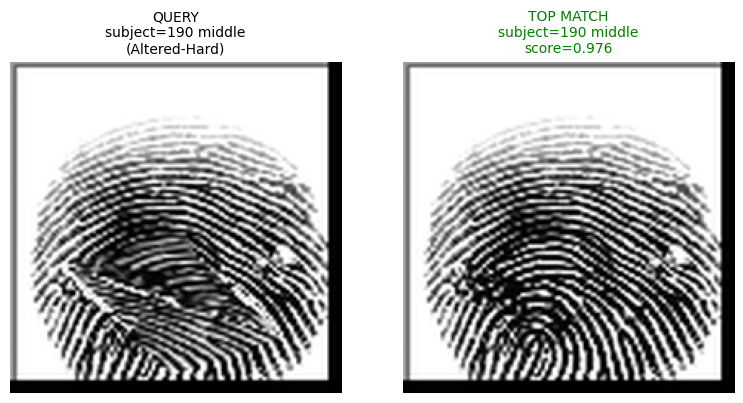

In [47]:
# ─── Full identification + database lookup for ONE sample ────────────────────
import sqlite3

DB_PATH = '/content/nbis_database/nbis.db'

# 1. Pick a random query image (not in the enrollment index)
test_sample     = df_query.sample(1, random_state=None).iloc[0]
test_image_path = test_sample['path']

print('=' * 65)
print('  QUERY')
print('=' * 65)
print(f'  Image path    : {test_image_path}')
print(f'  True identity : subject={test_sample["subject_id"]} '
      f'{test_sample["hand"]} {test_sample["finger"]}')
print(f'  Alteration    : {test_sample["alteration"]}')

# 2. Run identification
result = identify_fingerprint(
    image_path = test_image_path,
    model      = best_model,
    index      = faiss_inference,
    mapping    = mapping_inference,
    threshold  = OPTIMAL_THRESHOLD,
    img_size   = CONFIG['img_size'],
    top_k      = 5,
)

print('\n' + '=' * 65)
print('  MATCH RESULT')
print('=' * 65)
print(f'  Status        : {result["status"]}')
print(f'  Confidence    : {result["confidence"]}')
print(f'  Similarity    : {result["similarity"]:.4f}')
print(f'  Threshold     : {result["threshold_used"]:.4f}')

if result['status'] != 'MATCH':
    print('\n  ❌ Below threshold — no identity record fetched.')
else:
    pred_sid      = result['subject_id']
    pred_identity = result['identity_id']
    true_identity = test_sample['identity_id']
    is_correct    = (pred_identity == true_identity)

    print(f'  Predicted     : subject={pred_sid} '
          f'{result["hand"]} {result["finger"]}')
    print(f'  Correct?      : {"✅ YES" if is_correct else "❌ NO"}  '
          f'(true={true_identity}, pred={pred_identity})')

    # 3. Fetch full record from SQLite via JOIN across all tables
    conn = sqlite3.connect(DB_PATH)
    db_row = pd.read_sql_query("""
        SELECT
            s.subject_id, s.full_name AS child_name, s.gender AS child_gender,
            s.birth_datetime, s.weight_kg, s.blood_group AS child_blood,

            f.full_name AS father_name, f.national_id AS father_nid,
            f.birth_date AS father_dob, f.blood_group AS father_blood,
            f.phone AS father_phone, f.email AS father_email, f.city AS father_city,

            m.full_name AS mother_name, m.national_id AS mother_nid,
            m.birth_date AS mother_dob, m.blood_group AS mother_blood,
            m.phone AS mother_phone, m.email AS mother_email, m.city AS mother_city,

            h.hospital_name, h.city AS hospital_city, h.phone AS hospital_phone,
            h.address AS hospital_address
        FROM subjects  s
        JOIN fathers   f ON s.father_id   = f.father_id
        JOIN mothers   m ON s.mother_id   = m.mother_id
        JOIN hospitals h ON s.hospital_id = h.hospital_id
        WHERE s.subject_id = ?
    """, conn, params=(pred_sid,))
    conn.close()

    if len(db_row) == 0:
        print(f'\n  ⚠️  No DB record found for subject_id={pred_sid}')
    else:
        r = db_row.iloc[0]
        print('\n' + '=' * 65)
        print('  IDENTIFIED NEWBORN — FULL RECORD')
        print('=' * 65)
        print(f'  👶 Child')
        print(f'     Name          : {r["child_name"]}')
        print(f'     Subject ID    : {r["subject_id"]}')
        print(f'     Gender        : {r["child_gender"]}')
        print(f'     Birth date    : {r["birth_datetime"]}')
        print(f'     Weight        : {r["weight_kg"]}')
        print(f'     Blood group   : {r["child_blood"]}')

        print(f'\n  👨 Father')
        print(f'     Name          : {r["father_name"]}')
        print(f'     National ID   : {r["father_nid"]}')
        print(f'     Birth date    : {r["father_dob"]}')
        print(f'     Blood group   : {r["father_blood"]}')
        print(f'     Phone         : {r["father_phone"]}')
        print(f'     Email         : {r["father_email"]}')
        print(f'     City          : {r["father_city"]}')

        print(f'\n  👩 Mother')
        print(f'     Name          : {r["mother_name"]}')
        print(f'     National ID   : {r["mother_nid"]}')
        print(f'     Birth date    : {r["mother_dob"]}')
        print(f'     Blood group   : {r["mother_blood"]}')
        print(f'     Phone         : {r["mother_phone"]}')
        print(f'     Email         : {r["mother_email"]}')
        print(f'     City          : {r["mother_city"]}')

        print(f'\n  🏥 Hospital (registered birth location)')
        print(f'     Name          : {r["hospital_name"]}')
        print(f'     City          : {r["hospital_city"]}')
        print(f'     Phone         : {r["hospital_phone"]}')
        print(f'     Address       : {r["hospital_address"]}')

# 4. Show the query image alongside the top-K matches
print('\n' + '=' * 65)
print(f'  TOP-{len(result.get("top_k_results", []))} CANDIDATES')
print('=' * 65)
for r in result.get('top_k_results', []):
    flag = '✓' if r['identity_id'] == test_sample['identity_id'] else ' '
    print(f'  {flag}  Rank {r["rank"]}: subject={r["subject_id"]} '
          f'finger={r["finger"]:<7s}  similarity={r["score"]:.4f}')

# 5. Visualize query image + top match side-by-side
if result['status'] == 'MATCH':
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    query_img = preprocess_image(test_image_path, CONFIG['img_size'])
    axes[0].imshow(query_img[:, :, 0], cmap='gray')
    axes[0].set_title(f'QUERY\nsubject={test_sample["subject_id"]} '
                      f'{test_sample["finger"]}\n({test_sample["alteration"]})',
                      fontsize=10)
    axes[0].axis('off')

    # Find an enrollment image of the predicted identity to display
    match_row = df_enroll[df_enroll['identity_id'] == pred_identity]
    if len(match_row) > 0:
        match_img = preprocess_image(match_row.iloc[0]['path'], CONFIG['img_size'])
        axes[1].imshow(match_img[:, :, 0], cmap='gray')
        color = 'green' if is_correct else 'red'
        axes[1].set_title(f'TOP MATCH\nsubject={pred_sid} {result["finger"]}\n'
                          f'score={result["similarity"]:.3f}',
                          fontsize=10, color=color)
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [40]:
import os
import shutil
from tqdm import tqdm

base_save_dir = os.path.join(CONFIG['output_dir'], 'saved_images')
val_dir   = os.path.join(base_save_dir, 'val')
query_dir = os.path.join(base_save_dir, 'query')

os.makedirs(val_dir, exist_ok=True)
os.makedirs(query_dir, exist_ok=True)

# ─── Copy VAL images ─────────────────────────────────────────────
print("Copying VAL images...")
for _, row in tqdm(df_val.iterrows(), total=len(df_val)):
    src = row['path']
    dst = os.path.join(val_dir, os.path.basename(src))
    if not os.path.exists(dst):
        shutil.copy(src, dst)

# ─── Copy QUERY images ───────────────────────────────────────────
print("Copying QUERY images...")
for _, row in tqdm(df_query.iterrows(), total=len(df_query)):
    src = row['path']
    dst = os.path.join(query_dir, os.path.basename(src))
    if not os.path.exists(dst):
        shutil.copy(src, dst)

print("✅ Images saved to:", base_save_dir)

Copying VAL images...


100%|██████████| 8295/8295 [00:03<00:00, 2455.76it/s]


Copying QUERY images...


100%|██████████| 7394/7394 [00:02<00:00, 3205.03it/s]

✅ Images saved to: ./nbis_artifacts_v2/saved_images


In [41]:
# ─── Copy VAL + QUERY images into export folders ────────────────────────────
import os
import shutil
from tqdm import tqdm

export_dir = "/content/export_dataset"
val_dir    = os.path.join(export_dir, "val")
query_dir  = os.path.join(export_dir, "query")

os.makedirs(val_dir, exist_ok=True)
os.makedirs(query_dir, exist_ok=True)

# Copy VAL
print("Copying VAL images...")
for _, row in tqdm(df_val.iterrows(), total=len(df_val)):
    src = row['path']
    dst = os.path.join(val_dir, os.path.basename(src))
    if not os.path.exists(dst):
        shutil.copy(src, dst)

# Copy QUERY
print("Copying QUERY images...")
for _, row in tqdm(df_query.iterrows(), total=len(df_query)):
    src = row['path']
    dst = os.path.join(query_dir, os.path.basename(src))
    if not os.path.exists(dst):
        shutil.copy(src, dst)

print("✅ Images prepared at:", export_dir)

Copying VAL images...


100%|██████████| 8295/8295 [00:02<00:00, 3049.29it/s]


Copying QUERY images...


100%|██████████| 7394/7394 [00:03<00:00, 1853.52it/s]

✅ Images prepared at: /content/export_dataset


In [ ]:
# ─── Save artifacts with inference index ─────────────────────────────────────
save_artifacts(
    model       = best_model,
    faiss_index = faiss_inference,
    mapping     = mapping_inference,
    threshold   = OPTIMAL_THRESHOLD,
    config      = CONFIG,
    output_dir  = CONFIG['output_dir'],
)

# ─── Backup to Drive ──────────────────────────────────────────────────────────
from google.colab import drive, files
import shutil

drive.mount('/content/drive')
DRIVE_PATH = '/content/drive/MyDrive/NBIS_Final'
os.makedirs(DRIVE_PATH, exist_ok=True)

for item in os.listdir(CONFIG['output_dir']):
    src = os.path.join(CONFIG['output_dir'], item)
    dst = os.path.join(DRIVE_PATH, item)
    if os.path.isfile(src):
        shutil.copy(src, dst)

shutil.copytree(
    '/content/nbis_database',
    f'{DRIVE_PATH}/nbis_database',
    dirs_exist_ok=True
)
print('✅ Everything backed up to Drive!')

# ─── Download all artifacts to PC ─────────────────────────────────────────────
print('\nDownloading artifacts...')
files.download('./nbis_artifacts_v2/nbis_embedding_model.h5')
files.download('./nbis_artifacts_v2/nbis_faiss.index')
files.download('./nbis_artifacts_v2/nbis_index_mapping.pkl')
files.download('./nbis_artifacts_v2/nbis_threshold.json')
files.download('./nbis_artifacts_v2/nbis_preprocessing_config.json')
files.download('/content/nbis_database/nbis.db')
files.download('/content/nbis_database/parents.csv')
files.download('/content/nbis_database/subjects.csv')
files.download('/content/nbis_database/images.csv')
print('✅ All files downloading to your PC!')

✅ Model saved       : ./nbis_artifacts_v2/nbis_embedding_model.keras
✅ FAISS index saved : ./nbis_artifacts_v2/nbis_faiss.index
✅ Mapping saved     : ./nbis_artifacts_v2/nbis_index_mapping.pkl
✅ Threshold saved   : ./nbis_artifacts_v2/nbis_threshold.json
✅ Preproc config    : ./nbis_artifacts_v2/nbis_preprocessing_config.json

🎉 All NBIS artifacts saved to: ./nbis_artifacts_v2/
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Everything backed up to Drive!



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: /content/nbis_database/parents.csv

In [46]:
import sqlite3

csv_dir = '/content/nbis_database'
os.makedirs(csv_dir, exist_ok=True)

conn = sqlite3.connect(f'{csv_dir}/nbis.db')

pd.read_sql_query('SELECT * FROM subjects',  conn).to_csv(f'{csv_dir}/subjects.csv',  index=False)
pd.read_sql_query('SELECT * FROM fathers',   conn).to_csv(f'{csv_dir}/fathers.csv',   index=False)
pd.read_sql_query('SELECT * FROM mothers',   conn).to_csv(f'{csv_dir}/mothers.csv',   index=False)
pd.read_sql_query('SELECT * FROM hospitals', conn).to_csv(f'{csv_dir}/hospitals.csv', index=False)
pd.read_sql_query('SELECT * FROM images',    conn).to_csv(f'{csv_dir}/images.csv',    index=False)

# Consolidated parents CSV combining fathers + mothers with a role column
pd.read_sql_query("""
    SELECT father_id AS parent_id, 'father' AS role, full_name, national_id,
           birth_date, blood_group, phone, email, city
    FROM fathers
    UNION ALL
    SELECT mother_id AS parent_id, 'mother' AS role, full_name, national_id,
           birth_date, blood_group, phone, email, city
    FROM mothers
""", conn).to_csv(f'{csv_dir}/parents.csv', index=False)

conn.close()

print(f'✅ CSVs exported to {csv_dir}/')
for f in ['subjects', 'fathers', 'mothers', 'hospitals', 'images', 'parents']:
    print(f'   {f}.csv')

✅ CSVs exported to /content/nbis_database/
   subjects.csv
   fathers.csv
   mothers.csv
   hospitals.csv
   images.csv
   parents.csv


---
## Summary & Artifact Index (v2)

| Artifact | File | Description |
|---|---|---|
| Trained Model      | `nbis_embedding_model.keras` | MobileNetV2 + triplet head |
| Best Checkpoint    | `nbis_best_model_v2.keras`   | Saved at lowest val loss (v2) |
| FAISS Index        | `nbis_faiss.index`           | IndexFlatIP, cosine similarity |
| ID Mapping         | `nbis_index_mapping.pkl`     | FAISS idx → (subject, finger, parent) |
| Threshold          | `nbis_threshold.json`        | EER threshold from VAL (frozen) |
| Preprocessing      | `nbis_preprocessing_config.json` | Reproducible preprocessing |
| Training Plot      | `training_history.png`       | Loss curves |
| Evaluation Plot    | `evaluation_metrics.png`     | ROC / score dist / FAR-FRR |
| Distance Plot      | `embedding_distances.png`    | Intra vs inter-identity |
| Diagnostic Plot    | `diagnostic_d_prime.png`     | Val vs test separation |

---

## What v2 changed (and why it matters)

1. **Identity = (subject_id, finger).** Fingerprints are finger-specific;
   a per-subject matcher asks the model to learn a signal that isn\'t there.
2. **Training data now ~56k images** from Real + Altered-Easy + Altered-Medium
   + Altered-Hard, giving real same-finger-different-capture positive pairs.
3. **Memory-efficient tf.data pipeline** with lazy BMP decoding — training
   stays RAM-flat whether the dataset is 6k or 60k images.
4. **Enrollment/query split on identity** instead of subject — each test
   identity contributes half its images to enrollment, half to query, with
   Real preferred for enrollment and Altered for query.
5. **Threshold frozen on VAL** (never tuned on test) — the standard protocol
   for honest biometric benchmarking.
6. **Diagnostics** — d-prime, per-alteration, per-finger breakdowns so
   every number in your thesis can be defended.

---

## Limitations & future work (state these in your defense)

1. **Domain gap — adult vs newborn.** SOCOFing contains adult fingerprints.
   Newborn ridges are ~3–5× finer and softer; the model must be fine-tuned
   on neonatal data before clinical use. The Altered subsets give us
   *capture variability*, not *age variability*.
2. **Synthetic Altered ≠ real re-scan.** Altered-Easy/Medium/Hard are
   algorithmic perturbations. Real multi-session fingerprint re-acquisition
   (different devices, different pressure, different time) would be stronger
   supervision still.
3. **No template protection.** Raw embeddings cannot be revoked once leaked.
   Production requires cancelable biometrics / fuzzy commitment schemes.
4. **No liveness / quality checks.** NFIQ 2.0 quality gating and anti-spoofing
   are prerequisites for any real deployment.
5. **Scale.** 600 subjects is two orders of magnitude below commercial
   benchmarks. Real EER numbers at deployment scale (10k+ identities) will
   be worse than what you see here.
